# Exploratory Data Analysis — Control Station OCE Data

## Objective

This notebook explores the 3-minute PID loop dataset for one paper machine.

The purpose of the EDA is to:

1. Validate the structure and quality of the dataset.
2. Understand the behavior and distribution of OCE and related control metrics.
3. Identify differences in performance across PID loops.
4. Detect unusual time periods, loops, or operating patterns.
5. Identify potential drivers of poor control performance.
6. Establish a reliable analytical foundation for later benchmarking and economic-loss analysis.

> This notebook is exploratory. Patterns identified here should not automatically be interpreted as causal relationships.

### Data Quaylity Analysis

**Goal:** Identify missing values across dataset fields before analyzing PID-loop performance.

Missing values may affect OCE calculations, loop comparisons, and later benchmarking.


In [133]:
# Define the correct column names provided by Control Station
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columns = [
    "LoopId",
    "resulttime",
    "OverallUptime",
    "StictionValue",
    "OverallHealth",
    "OverallOCE",
    "PercentageTimeInNormalMode",
    "AbsErrGoodFrac",
    "AAE",
    "NormalizedVariation",
    "PV_Average",
    "PVVariance",
    "COTravel",
    "ReversalsPerHour",
    "PercentTimeSaturated"
]

df = pd.read_csv(
    "../data/raw/3-minute data Jul.csv",
    header=None,
    names=columns
)

df.head(10)

,LoopId,resulttime,OverallUptime,StictionValue,OverallHealth,OverallOCE,PercentageTimeInNormalMode,AbsErrGoodFrac,AAE,NormalizedVariation,PV_Average,PVVariance,COTravel,ReversalsPerHour,PercentTimeSaturated
0,5,2025-07-01 00:00:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,63.214645,4.215731,3459.438232,3004.931641,0.389972,120.0,0.0
1,5,2025-07-01 00:03:00.0000000 +00:00,100.0,0.0,58.333333,41.111111,1.0,0.411111,52.528877,3.696444,3459.736816,3519.830811,0.407352,100.0,0.0
2,5,2025-07-01 00:06:00.0000000 +00:00,100.0,0.0,63.664583,36.666668,1.0,0.366667,40.776787,2.744100,3439.315186,1320.311401,0.355343,80.0,0.0
3,5,2025-07-01 00:09:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,54.010696,3.581736,3459.701416,1991.939819,0.460078,180.0,0.0
4,5,2025-07-01 00:12:00.0000000 +00:00,100.0,0.0,58.333333,36.666668,1.0,0.366667,56.769093,3.680142,3471.993652,2706.926270,0.364381,120.0,0.0
5,5,2025-07-01 00:15:00.0000000 +00:00,100.0,0.0,58.333333,28.888889,1.0,0.288889,70.660530,4.868598,3497.090332,2741.852051,0.629808,180.0,0.0
6,5,2025-07-01 00:18:00.0000000 +00:00,100.0,0.0,58.333333,24.444445,1.0,0.244444,65.464050,3.959182,3521.630371,2824.932861,0.276270,80.0,0.0
7,5,2025-07-01 00:21:00.0000000 +00:00,100.0,0.0,83.511577,86.666664,1.0,0.866667,26.801765,1.791444,3372.719971,859.642273,0.131963,60.0,0.0
8,5,2025-07-01 00:24:00.0000000 +00:00,100.0,0.0,58.333333,33.333336,1.0,0.333333,68.247078,4.711651,3355.276611,1688.857178,0.505975,160.0,0.0
9,5,2025-07-01 00:27:00.0000000 +00:00,100.0,0.0,61.157808,85.555557,1.0,0.855556,34.887478,2.864425,3435.649170,3434.660889,0.226443,240.0,0.0


In [4]:
#inital data inspection
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 10 rows:")
display(df.head(10))

Dataset shape: (1201478, 15)

Columns:
['LoopId', 'resulttime', 'OverallUptime', 'StictionValue', 'OverallHealth', 'OverallOCE', 'PercentageTimeInNormalMode', 'AbsErrGoodFrac', 'AAE', 'NormalizedVariation', 'PV_Average', 'PVVariance', 'COTravel', 'ReversalsPerHour', 'PercentTimeSaturated']

Data types:
LoopId                          int64
resulttime                        str
OverallUptime                 float64
StictionValue                 float64
OverallHealth                 float64
OverallOCE                    float64
PercentageTimeInNormalMode    float64
AbsErrGoodFrac                float64
AAE                           float64
NormalizedVariation           float64
PV_Average                    float64
PVVariance                    float64
COTravel                      float64
ReversalsPerHour              float64
PercentTimeSaturated          float64
dtype: object

First 10 rows:


,LoopId,resulttime,OverallUptime,StictionValue,OverallHealth,OverallOCE,PercentageTimeInNormalMode,AbsErrGoodFrac,AAE,NormalizedVariation,PV_Average,PVVariance,COTravel,ReversalsPerHour,PercentTimeSaturated
0,5,2025-07-01 00:00:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,63.214645,4.215731,3459.438232,3004.931641,0.389972,120.0,0.0
1,5,2025-07-01 00:03:00.0000000 +00:00,100.0,0.0,58.333333,41.111111,1.0,0.411111,52.528877,3.696444,3459.736816,3519.830811,0.407352,100.0,0.0
2,5,2025-07-01 00:06:00.0000000 +00:00,100.0,0.0,63.664583,36.666668,1.0,0.366667,40.776787,2.744100,3439.315186,1320.311401,0.355343,80.0,0.0
3,5,2025-07-01 00:09:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,54.010696,3.581736,3459.701416,1991.939819,0.460078,180.0,0.0
4,5,2025-07-01 00:12:00.0000000 +00:00,100.0,0.0,58.333333,36.666668,1.0,0.366667,56.769093,3.680142,3471.993652,2706.926270,0.364381,120.0,0.0
5,5,2025-07-01 00:15:00.0000000 +00:00,100.0,0.0,58.333333,28.888889,1.0,0.288889,70.660530,4.868598,3497.090332,2741.852051,0.629808,180.0,0.0
6,5,2025-07-01 00:18:00.0000000 +00:00,100.0,0.0,58.333333,24.444445,1.0,0.244444,65.464050,3.959182,3521.630371,2824.932861,0.276270,80.0,0.0
7,5,2025-07-01 00:21:00.0000000 +00:00,100.0,0.0,83.511577,86.666664,1.0,0.866667,26.801765,1.791444,3372.719971,859.642273,0.131963,60.0,0.0
8,5,2025-07-01 00:24:00.0000000 +00:00,100.0,0.0,58.333333,33.333336,1.0,0.333333,68.247078,4.711651,3355.276611,1688.857178,0.505975,160.0,0.0
9,5,2025-07-01 00:27:00.0000000 +00:00,100.0,0.0,61.157808,85.555557,1.0,0.855556,34.887478,2.864425,3435.649170,3434.660889,0.226443,240.0,0.0


## 2. Data Structure and Coverage

Before analyzing control performance, we first establish the scope and temporal coverage of the dataset.

This section answers four basic questions:

- How many observations are available?
- How many unique PID loops are represented?
- What time period does the dataset cover?
- Is the expected 3-minute sampling interval consistent across the data?

In [5]:
#convert timestamp 
df["resulttime"] = pd.to_datetime(df["resulttime"], errors="coerce")

#basic dataset coverage
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Unique loops: {df['LoopId'].nunique():,}")
print(f"Start time: {df['resulttime'].min()}")
print(f"End time: {df['resulttime'].max()}")

Number of rows: 1,201,478
Number of columns: 15
Unique loops: 94
Start time: 2025-07-01 00:00:00+00:00
End time: 2025-07-31 23:57:00+00:00


### 2.1 Observations by Loop

Next, we examine how many observations are available for each PID loop.

Large differences in record counts may indicate incomplete coverage, differences in loop availability, or other data-quality issues that should be investigated before comparing loop performance.

In [6]:
#foundation statiscal 
loop_counts = (
    df.groupby("LoopId")
      .size()
      .sort_values(ascending=False)
)

display(loop_counts.describe())

display(loop_counts.head(10))
display(loop_counts.tail(10))

count       94.000000
mean     12781.680851
std       3352.384278
min          3.000000
25%      13607.000000
50%      13607.000000
75%      14067.000000
max      14880.000000
dtype: float64

LoopId
5      14880
439    14857
312    14769
458    14235
438    14235
466    14235
461    14235
462    14235
460    14235
463    14235
dtype: int64

LoopId
293    12421
297    11041
425     7855
421     7853
440     1852
441     1670
295       11
294       11
420        3
422        3
dtype: int64

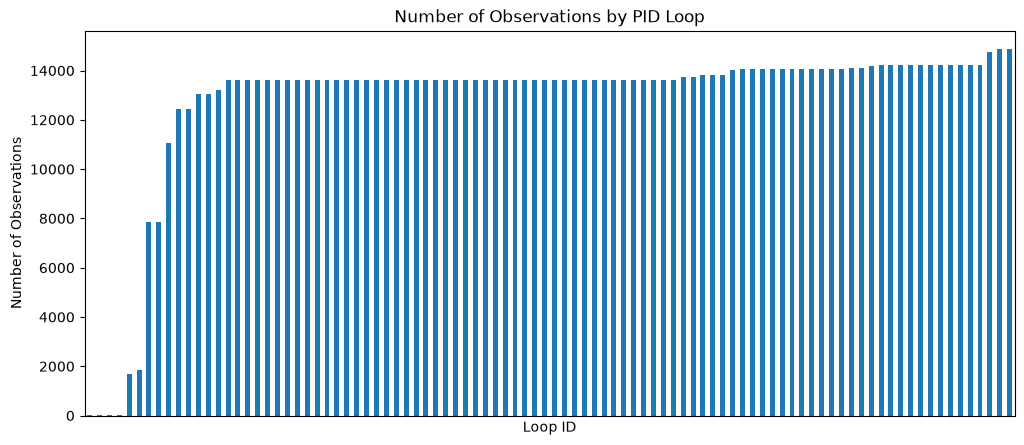

In [7]:
#visualize number of observation by PID loop
plt.figure(figsize=(12, 5))

loop_counts.sort_values().plot(kind="bar")

plt.title("Number of Observations by PID Loop")
plt.xlabel("Loop ID")
plt.ylabel("Number of Observations")
plt.xticks([])
plt.show()

### Time Coverage Analysis


In [8]:
#sort data before time analysis 
df = df.sort_values(
    ["LoopId", "resulttime"]
).reset_index(drop=True)

In [9]:
df["time_diff"] = (
    df.groupby("LoopId")["resulttime"]
      .diff()
)

df["time_diff"].value_counts().head(10)

time_diff
0 days 00:03:00    1199598
0 days 00:30:00        242
0 days 00:45:00        138
0 days 01:00:00        112
0 days 00:51:00        104
0 days 00:42:00         97
0 days 00:09:00         64
0 days 01:51:00         54
0 days 01:12:00         53
0 days 07:00:00         51
Name: count, dtype: int64

In [10]:
# Remove NaT values from the first observation of each loop
valid_diff = df["time_diff"].dropna()

# Calculate the percentage of intervals that are exactly 3 minutes
three_min_pct = (
    valid_diff.eq(pd.Timedelta(minutes=3)).mean() * 100
)

print(f"Intervals exactly 3 minutes apart: {three_min_pct:.2f}%")

Intervals exactly 3 minutes apart: 99.85%


In [11]:
# Calculate the percentage of intervals greater than 3 minutes
gap_pct = (
    (valid_diff > pd.Timedelta(minutes=3)).mean() * 100
)

print(f"Intervals greater than 3 minutes: {gap_pct:.2f}%")

Intervals greater than 3 minutes: 0.15%


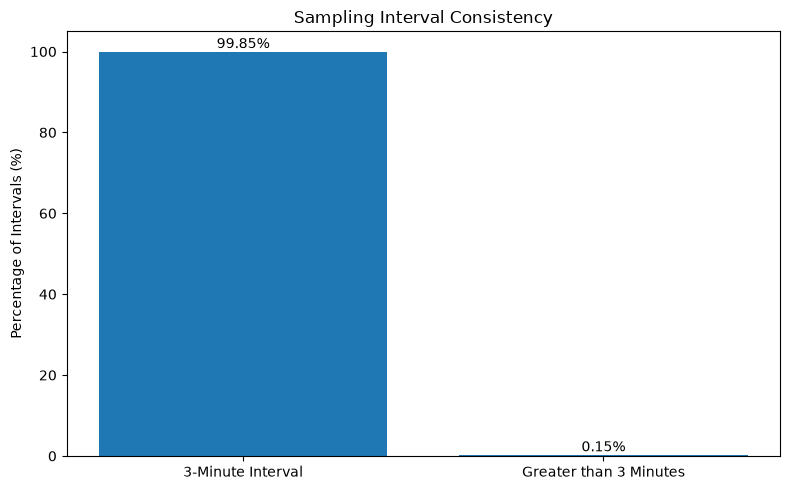

In [12]:
# Classify intervals as expected (3 minutes) or irregular (>3 minutes)
interval_summary = pd.Series({
    "3-Minute Interval":
        (valid_diff == pd.Timedelta(minutes=3)).sum(),

    "Greater than 3 Minutes":
        (valid_diff > pd.Timedelta(minutes=3)).sum()
})

# Convert counts into percentages
interval_pct = (
    interval_summary / interval_summary.sum() * 100
)

# Visualize sampling consistency
plt.figure(figsize=(8, 5))

bars = plt.bar(
    interval_pct.index,
    interval_pct.values
)

plt.title("Sampling Interval Consistency")
plt.ylabel("Percentage of Intervals (%)")
plt.ylim(0, 105)

# Add percentage labels above each bar
for bar, value in zip(bars, interval_pct.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [13]:
# Identify observations where the previous record is more than 3 minutes away
gaps = df[
    df["time_diff"] > pd.Timedelta(minutes=3)
]

# Count the total number of detected time gaps
print(f"Number of intervals > 3 minutes: {len(gaps):,}")

Number of intervals > 3 minutes: 1,786


In [14]:
# Find the 20 largest time gaps in the dataset
largest_gaps = (
    gaps[
        ["LoopId", "resulttime", "time_diff"]
    ]
    .sort_values("time_diff", ascending=False)
    .head(20)
)

# Display the largest gaps
display(largest_gaps)

,LoopId,resulttime,time_diff
670182,441,2025-07-27 08:12:00+00:00,8 days 09:12:00
520016,421,2025-07-23 09:06:00+00:00,4 days 12:06:00
527872,425,2025-07-23 09:06:00+00:00,4 days 12:06:00
670168,441,2025-07-18 22:21:00+00:00,3 days 07:21:00
669105,440,2025-07-21 14:12:00+00:00,2 days 09:12:00
528748,425,2025-07-27 08:36:00+00:00,1 days 14:45:00
520892,421,2025-07-27 08:36:00+00:00,1 days 14:45:00
517600,421,2025-07-12 11:06:00+00:00,1 days 11:36:00
525456,425,2025-07-12 11:06:00+00:00,1 days 11:36:00
515959,421,2025-07-06 23:21:00+00:00,1 days 08:30:00


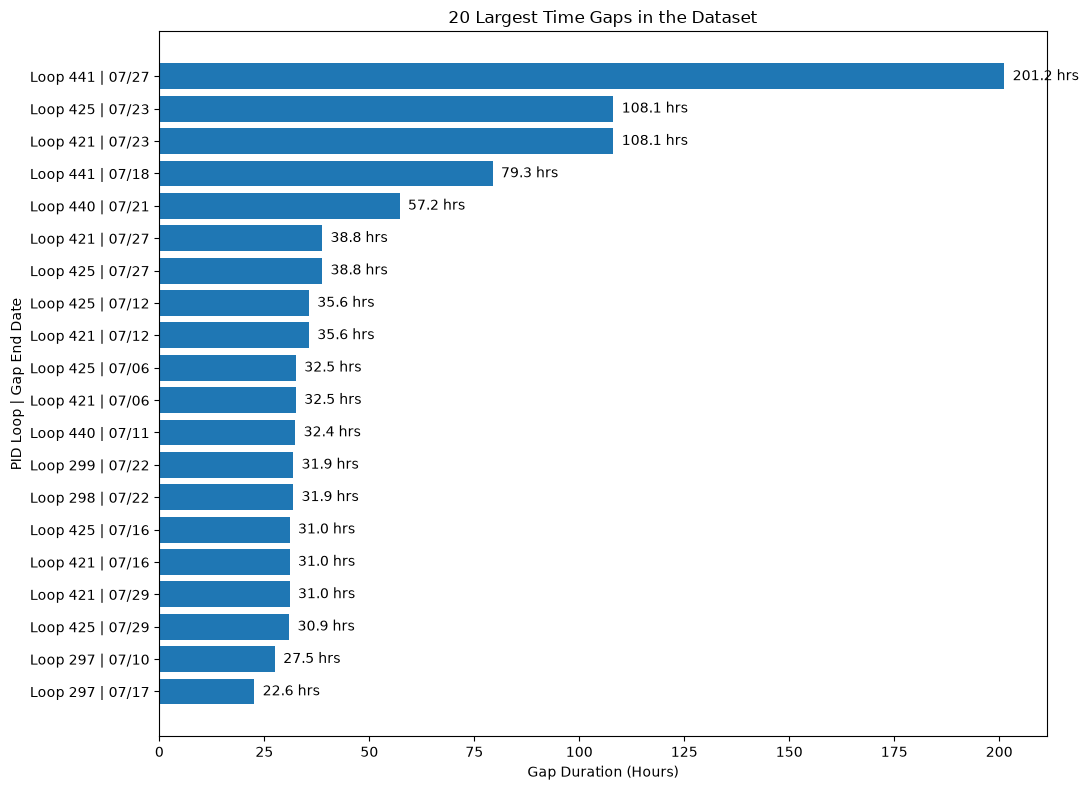

In [15]:
# Convert gap duration into hours for easier visualization
largest_gaps["gap_hours"] = (
    largest_gaps["time_diff"].dt.total_seconds() / 3600
)

# Create labels using Loop ID and gap end date
largest_gaps["label"] = (
    "Loop "
    + largest_gaps["LoopId"].astype(str)
    + " | "
    + largest_gaps["resulttime"].dt.strftime("%m/%d")
)

# Sort for horizontal bar chart
largest_gaps_plot = largest_gaps.sort_values(
    "gap_hours",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(11, 8))

bars = plt.barh(
    largest_gaps_plot["label"],
    largest_gaps_plot["gap_hours"]
)

# Add gap duration next to each bar
for bar in bars:
    width = bar.get_width()
    
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f} hrs",
        va="center"
    )

# Add chart title and labels
plt.title("20 Largest Time Gaps in the Dataset")
plt.xlabel("Gap Duration (Hours)")
plt.ylabel("PID Loop | Gap End Date")

plt.tight_layout()
plt.show()

In [16]:
# Reverse the order so the loop with the most gaps appears at the top
top_15_plot = top_15_gaps.sort_values(ascending=True)

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_15_plot.index.astype(str),
    top_15_plot.values
)

# Add the exact number of gaps next to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

# Add chart title and axis labels
plt.title("Top 15 PID Loops with the Most Time Gaps")
plt.xlabel("Number of Time Gaps (> 3 Minutes)")
plt.ylabel("Loop ID")

plt.tight_layout()
plt.show()

NameError: name 'top_15_gaps' is not defined

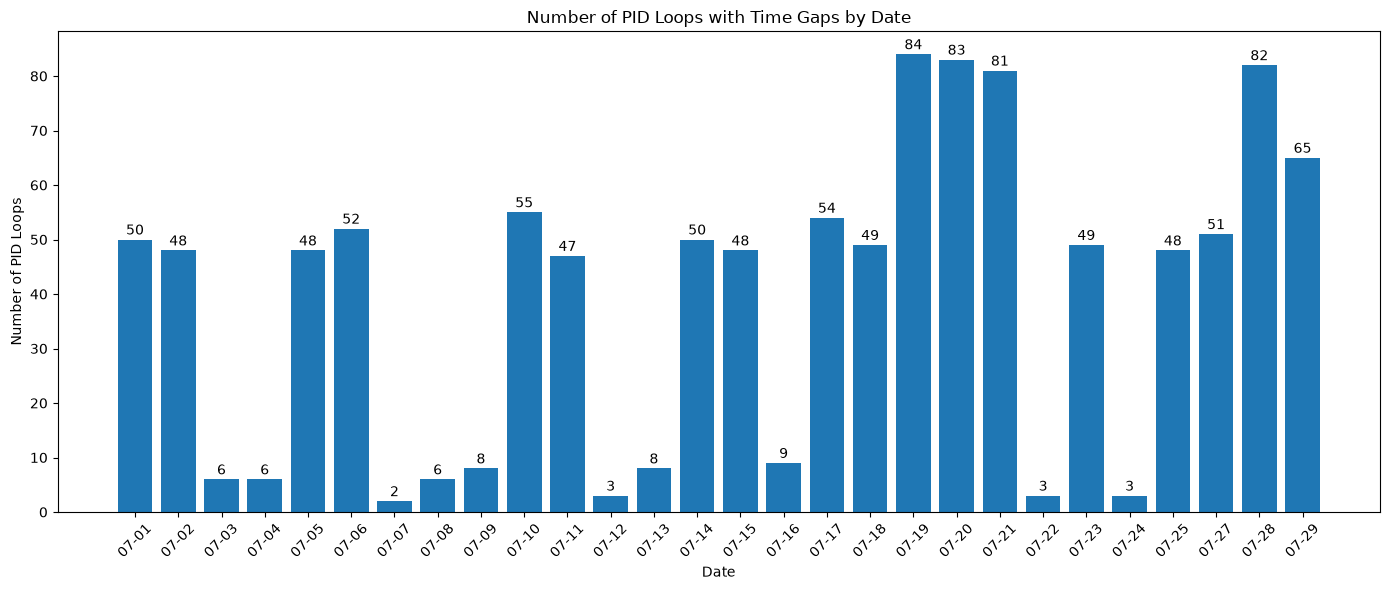

In [ ]:
# Count how many PID loops experienced at least one gap on each date
loops_with_gap_per_day = gap_matrix.sum(axis=0)

# Keep only dates where at least 2 loops experienced gaps
shared_gap_days = loops_with_gap_per_day[
    loops_with_gap_per_day >= 2
].sort_index()


# -----------------------------
# Visualization
# -----------------------------

plt.figure(figsize=(14, 6))

bars = plt.bar(
    [str(date)[5:] for date in shared_gap_days.index],
    shared_gap_days.values
)

# Add the number of affected loops above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.title("Number of PID Loops with Time Gaps by Date")
plt.xlabel("Date")
plt.ylabel("Number of PID Loops")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Data Quaylity Analysis

**Goal:** Identify missing values across dataset fields before analyzing PID-loop performance.

Missing values may affect OCE calculations, loop comparisons, and later benchmarking.


In [ ]:
# Create and calculate missing count and percentage for each variable
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

# Sort from highest to lowest missing percentage
missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percent
StictionValue,348207,28.981554
OverallOCE,2280,0.189766
ReversalsPerHour,2280,0.189766
PercentTimeSaturated,2280,0.189766
COTravel,2280,0.189766
AAE,1176,0.097879
PV_Average,1176,0.097879
PVVariance,1176,0.097879
PercentageTimeInNormalMode,0,0.000000
resulttime,0,0.000000


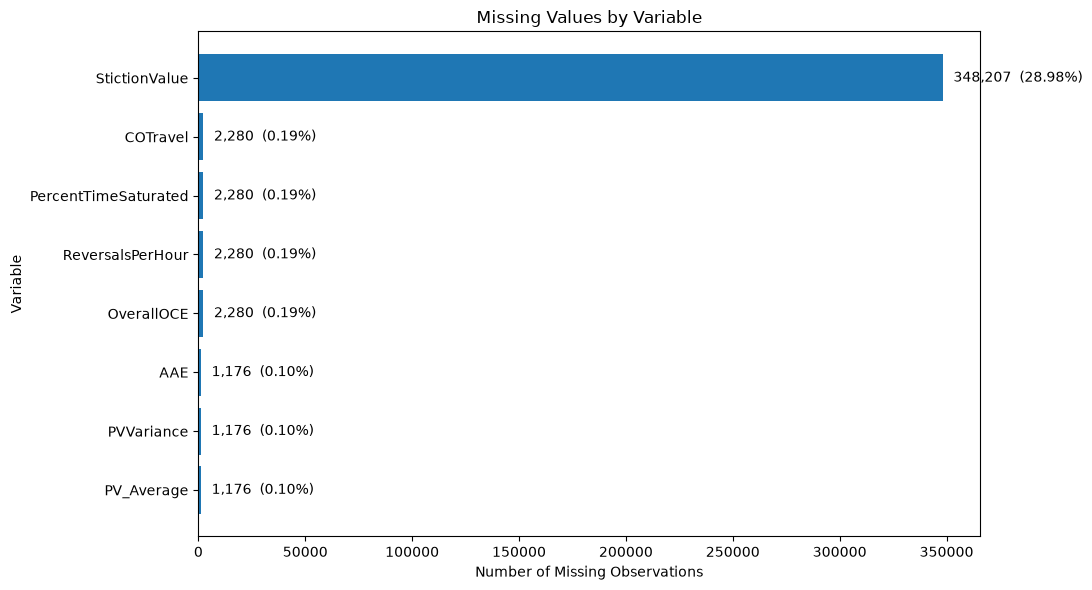

In [ ]:
# Keep only variables with missing values
missing_plot = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count")


# Create horizontal bar chart
plt.figure(figsize=(11, 6))

bars = plt.barh(
    missing_plot.index,
    missing_plot["missing_count"]
)

# Add both missing count and percentage as labels
for bar, (_, row) in zip(bars, missing_plot.iterrows()):
    
    count = row["missing_count"]
    percent = row["missing_percent"]

    plt.text(
        bar.get_width() + 5000,
        bar.get_y() + bar.get_height() / 2,
        f'{int(count):,}  ({percent:.2f}%)',
        va="center"
    )

plt.title("Missing Values by Variable")
plt.xlabel("Number of Missing Observations")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

### Missing Pattern
- Focus on stiction

In [ ]:
# Select variables that contain missing values
missing_cols = [
    "StictionValue",
    "OverallOCE",
    "ReversalsPerHour",
    "PercentTimeSaturated",
    "COTravel",
    "AAE",
    "PV_Average",
    "PVVariance"
]

# Create a missing-value indicator
# 1 = Missing, 0 = Available
missing_pattern = df[missing_cols].isna().astype(int)

# Count the most common combinations of missing values
pattern_counts = (
    missing_pattern
    .value_counts()
    .reset_index(name="observations")
)

display(pattern_counts.head(10))

,StictionValue,OverallOCE,ReversalsPerHour,PercentTimeSaturated,COTravel,AAE,PV_Average,PVVariance,observations
0,0,0,0,0,0,0,0,0,853271
1,1,0,0,0,0,0,0,0,344830
2,1,1,1,1,1,0,0,0,2201
3,1,0,0,0,0,1,1,1,1097
4,1,1,1,1,1,1,1,1,79


In [ ]:
# Calculate StictionValue missing percentage for each PID loop
stiction_by_loop = (
    df.groupby("LoopId")["StictionValue"]
      .apply(lambda x: x.isna().mean() * 100)
      .sort_values(ascending=False)
)

display(stiction_by_loop)

LoopId
295    100.000000
294    100.000000
395    100.000000
422    100.000000
466    100.000000
          ...    
401      0.308665
439      0.296157
462      0.288022
446      0.227483
421      0.191010
Name: StictionValue, Length: 94, dtype: float64

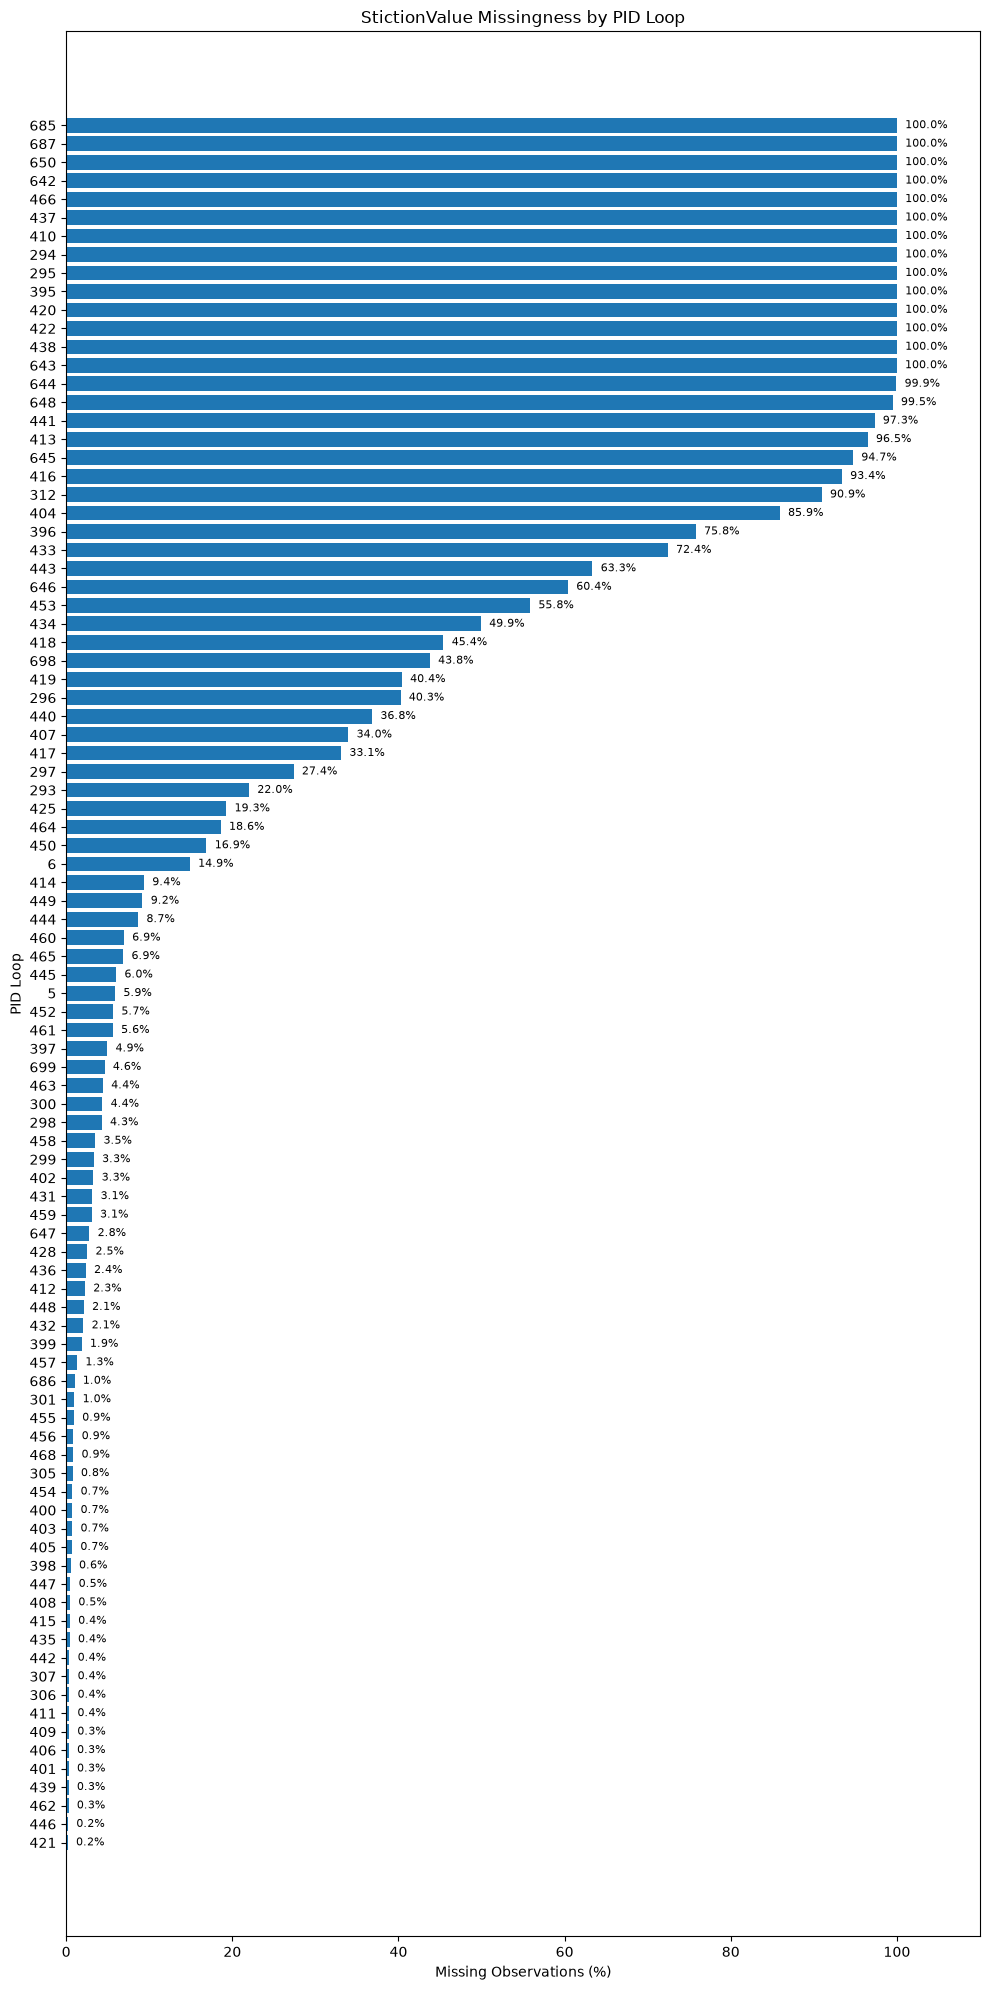

In [ ]:
# Calculate StictionValue missing percentage for each PID loop
stiction_by_loop = (
    df.groupby("LoopId")["StictionValue"]
      .apply(lambda x: x.isna().mean() * 100)
      .sort_values(ascending=True)
)


# Create horizontal bar chart for ALL PID loops
plt.figure(figsize=(10, 20))

bars = plt.barh(
    stiction_by_loop.index.astype(str),
    stiction_by_loop.values
)

# Add percentage labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=8
    )

plt.title("StictionValue Missingness by PID Loop")
plt.xlabel("Missing Observations (%)")
plt.ylabel("PID Loop")

plt.xlim(0, 110)
plt.tight_layout()
plt.show()

### Duplicate Check 

In [17]:
# Check for exact duplicate rows
exact_duplicates = df.duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicates:,}")
print(f"Percentage of dataset: {exact_duplicates / len(df) * 100:.4f}%")

Exact duplicate rows: 0
Percentage of dataset: 0.0000%


In [32]:
# Select numeric variables for range validation
numeric_cols = [
    "OverallUptime",
    "StictionValue",
    "OverallHealth",
    "OverallOCE",
    "PercentageTimeInNormalMode",
    "AbsErrGoodFrac",
    "AAE",
    "NormalizedVariation",
    "PV_Average",
    "PVVariance",
    "COTravel",
    "ReversalsPerHour",
    "PercentTimeSaturated"
]

# Review the distribution and range of each numeric variable
range_summary = df[numeric_cols].describe().T

# Display values with 2 decimal places and no scientific notation
display(
    range_summary.style.format("{:,.2f}")
)

,count,mean,std,min,25%,50%,75%,max
OverallUptime,"1,201,478.00",99.89,2.44,32.97,100.00,100.00,100.00,100.00
StictionValue,"853,271.00",0.01,0.06,0.00,0.00,0.00,0.00,1.00
OverallHealth,"1,201,478.00",77.50,23.55,0.00,58.33,83.11,100.00,100.00
OverallOCE,"1,199,198.00",54.44,38.50,0.00,13.33,61.11,94.44,100.00
PercentageTimeInNormalMode,"1,201,478.00",0.94,0.24,0.00,1.00,1.00,1.00,1.00
AbsErrGoodFrac,"1,201,478.00",0.64,0.36,0.00,0.37,0.73,1.00,1.00
AAE,"1,200,302.00",15.97,65.42,0.00,0.08,0.41,3.58,"5,870.49"
NormalizedVariation,"1,201,478.00","4,131.51","207,777.15",0.00,0.63,1.81,5.44,"60,094,159.93"
PV_Average,"1,200,302.00",377.65,851.02,-499.67,7.12,59.98,327.14,"11,519.61"
PVVariance,"1,200,302.00",167.65,"19,721.56",0.00,0.00,0.05,1.71,"12,878,021.15"


### Insights

OCE varies widely: OverallOCE ranges from 0–100, with a median of 61.11, indicating substantial variation in control performance.

Normal Mode is consistently high: At least 75% of observations have PercentageTimeInNormalMode = 1.

Saturation is uncommon: At least 75% of observations have PercentTimeSaturated = 0.

Several process metrics are highly right-skewed: NormalizedVariation, PVVariance, AAE, and COTravel contain extreme upper values that strongly exceed their medians.

StictionValue is mostly zero when available: Its median and 75th percentile are both 0, while 28.98% of observations are missing.

## 3. Overall Machine Performance

### 3.1 Machine Summary

In [ ]:
# OVERALL MACHINE PERFORMANCE


import pandas as pd

# Make sure resulttime is datetime
df["resulttime"] = pd.to_datetime(df["resulttime"])

# Basic machine information
start_date = df["resulttime"].min()
end_date = df["resulttime"].max()

num_loops = df["LoopId"].nunique()
total_observations = len(df)

# OCE summary
oce = df["OverallOCE"]

mean_oce = oce.mean()
median_oce = oce.median()
std_oce = oce.std()

p10 = oce.quantile(0.10)
p25 = oce.quantile(0.25)
p75 = oce.quantile(0.75)
p90 = oce.quantile(0.90)

min_oce = oce.min()
max_oce = oce.max()

missing_oce = oce.isna().sum()

# IQR
iqr = p75 - p25


# ==========================================
# Display Summary
# ==========================================

machine_summary = pd.DataFrame({
    "Metric": [
        "Start Date",
        "End Date",
        "Unique Loops",
        "Total Observations",
        "Mean OCE",
        "Median OCE",
        "OCE Std Dev",
        "P10",
        "P25",
        "P75",
        "P90",
        "IQR",
        "Minimum OCE",
        "Maximum OCE",
        "Missing OCE"
    ],

    "Value": [
        start_date,
        end_date,
        num_loops,
        total_observations,
        mean_oce,
        median_oce,
        std_oce,
        p10,
        p25,
        p75,
        p90,
        iqr,
        min_oce,
        max_oce,
        missing_oce
    ]
})

machine_summary

,Metric,Value
0,Start Date,2025-07-01 00:00:00+00:00
1,End Date,2025-07-31 23:57:00+00:00
2,Unique Loops,94
3,Total Observations,1201478
4,Mean OCE,54.442876
5,Median OCE,61.111111
6,OCE Std Dev,38.497919
7,P10,0.0
8,P25,13.333334
9,P75,94.444443


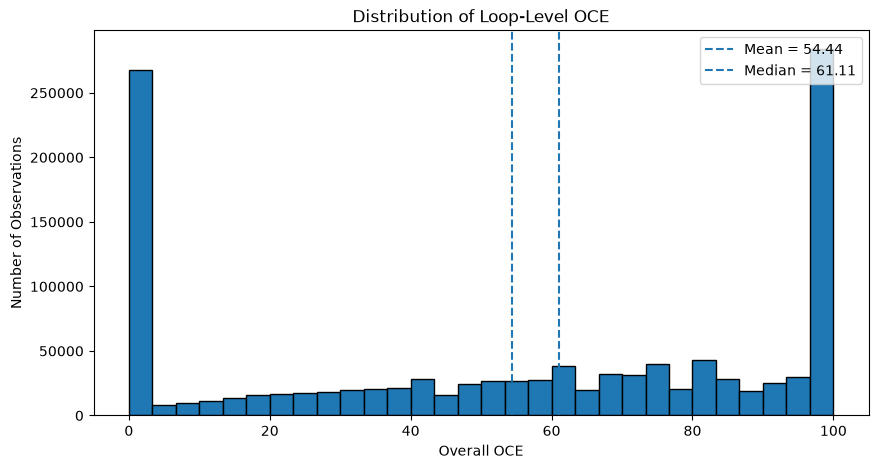

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["OverallOCE"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.axvline(
    df["OverallOCE"].mean(),
    linestyle="--",
    label=f"Mean = {df['OverallOCE'].mean():.2f}"
)

plt.axvline(
    df["OverallOCE"].median(),
    linestyle="--",
    label=f"Median = {df['OverallOCE'].median():.2f}"
)

plt.title("Distribution of Loop-Level OCE")
plt.xlabel("Overall OCE")
plt.ylabel("Number of Observations")

plt.legend()
plt.show()

In [33]:
# OCE Distribution by Range
# Create descriptive OCE ranges
oce_bins = pd.cut(
    df["OverallOCE"],
    bins=[0, 20, 40, 60, 80, 100],
    include_lowest=True,
    labels=[
        "0–20",
        "20–40",
        "40–60",
        "60–80",
        "80–100"
    ]
)

# Count observations in each OCE range
oce_range_summary = (
    oce_bins
    .value_counts(sort=False)
    .to_frame("observations")
)

# Calculate percentage of valid OCE observations
oce_range_summary["percentage"] = (
    oce_range_summary["observations"]
    / df["OverallOCE"].notna().sum()
    * 100
)

display(oce_range_summary)

,observations,percentage
OverallOCE,,
0–20,331843,27.672078
20–40,114419,9.541293
40–60,142625,11.893365
60–80,191476,15.967005
80–100,418835,34.926259


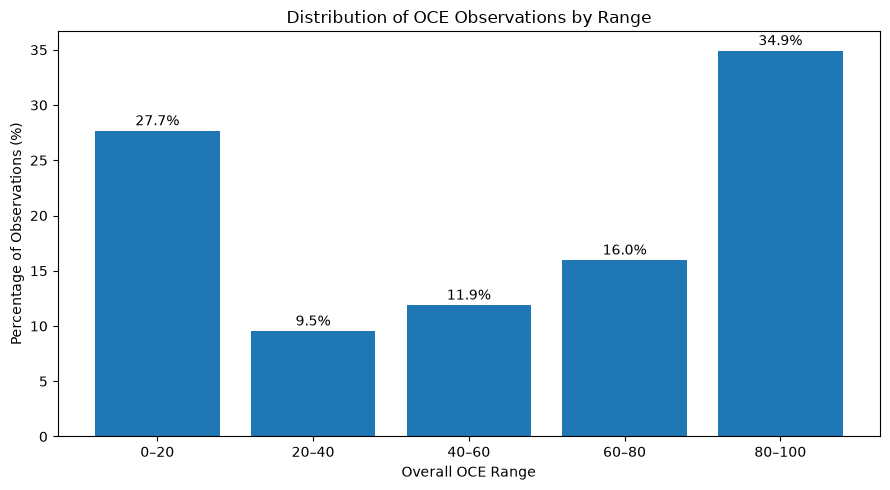

In [34]:
# Visualize OCE observations by range
plt.figure(figsize=(9, 5))

bars = plt.bar(
    oce_range_summary.index.astype(str),
    oce_range_summary["percentage"]
)

# Add percentage labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center"
    )

plt.title("Distribution of OCE Observations by Range")
plt.xlabel("Overall OCE Range")
plt.ylabel("Percentage of Observations (%)")

plt.tight_layout()
plt.show()

### 3.2 Time Analysis


In [118]:
# ==========================================
# 1.2 TIME PERFORMANCE
# Hourly Machine Performance
# ==========================================

hourly_performance = (
    df.set_index("resulttime")
      .resample("1h")["OverallOCE"]
      .agg(["mean", "median", "std", "count"])
      .reset_index()
)

hourly_performance.head()

,resulttime,mean,median,std,count
0,2025-07-01 00:00:00+00:00,55.189946,62.222225,38.527916,1680
1,2025-07-01 01:00:00+00:00,56.438652,62.222225,38.489665,1683
2,2025-07-01 02:00:00+00:00,55.988096,61.111111,38.338566,1680
3,2025-07-01 03:00:00+00:00,57.775794,64.444443,37.825755,1680
4,2025-07-01 04:00:00+00:00,58.645743,66.666672,37.723541,1680


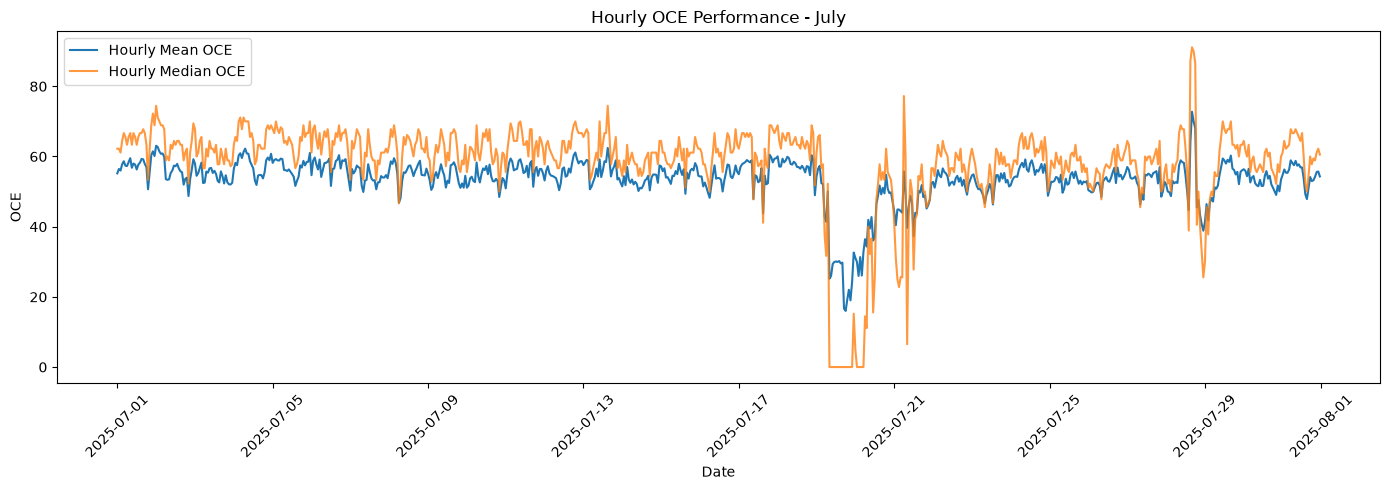

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    hourly_performance["resulttime"],
    hourly_performance["mean"],
    label="Hourly Mean OCE"
)

plt.plot(
    hourly_performance["resulttime"],
    hourly_performance["median"],
    label="Hourly Median OCE",
    alpha=0.8
)

plt.title("Hourly OCE Performance - July")
plt.xlabel("Date")
plt.ylabel("OCE")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [120]:
daily_performance = (
    df.set_index("resulttime")
      .resample("1D")["OverallOCE"]
      .agg(["mean", "median", "std", "count"])
      .reset_index()
)

daily_performance.head()

,resulttime,mean,median,std,count
0,2025-07-01 00:00:00+00:00,57.655423,64.444443,38.425955,39877
1,2025-07-02 00:00:00+00:00,56.679244,64.444443,38.380176,40532
2,2025-07-03 00:00:00+00:00,54.627178,61.111111,38.182388,40426
3,2025-07-04 00:00:00+00:00,57.819386,65.555557,37.978957,42108
4,2025-07-05 00:00:00+00:00,57.129668,65.555557,38.387662,40970


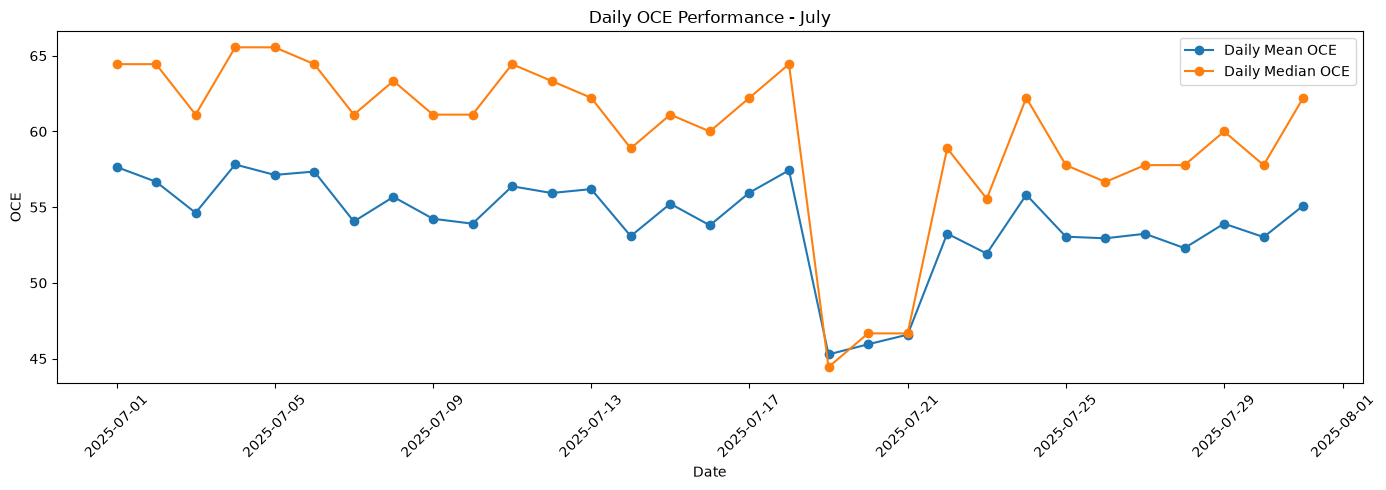

In [121]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_performance["resulttime"],
    daily_performance["mean"],
    marker="o",
    label="Daily Mean OCE"
)

plt.plot(
    daily_performance["resulttime"],
    daily_performance["median"],
    marker="o",
    label="Daily Median OCE"
)

plt.title("Daily OCE Performance - July")
plt.xlabel("Date")
plt.ylabel("OCE")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

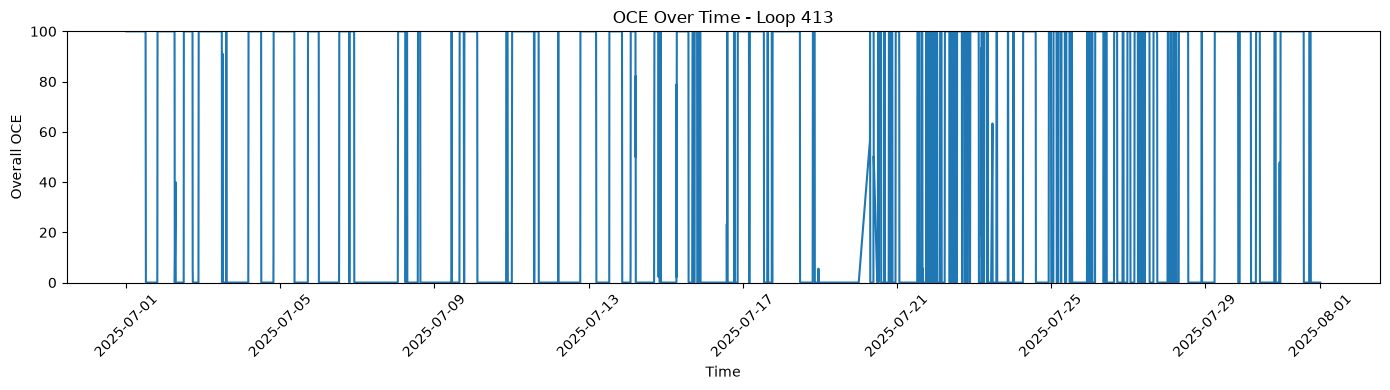

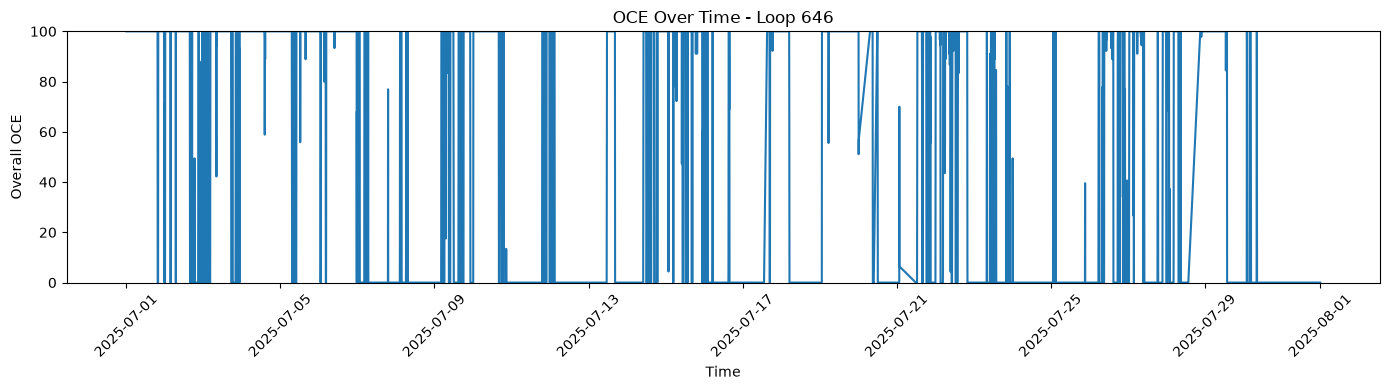

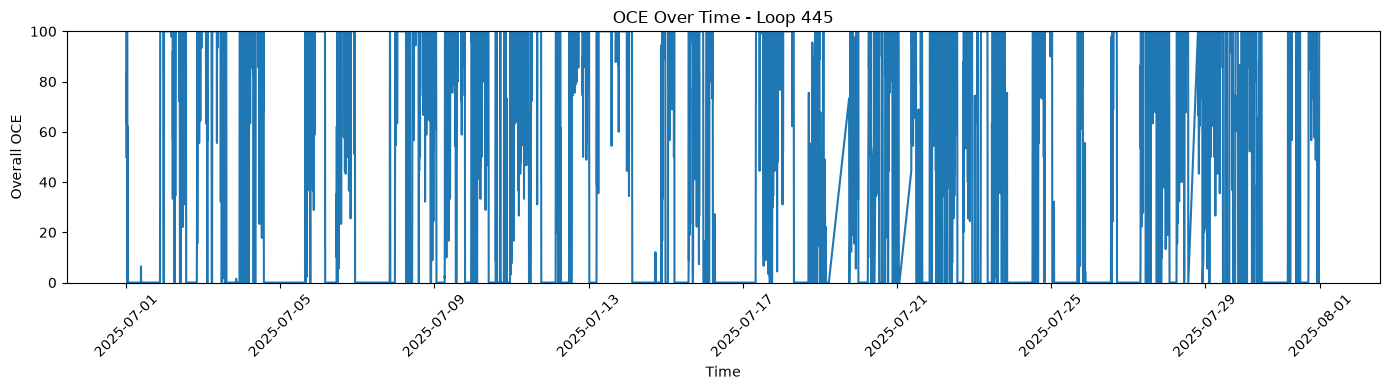

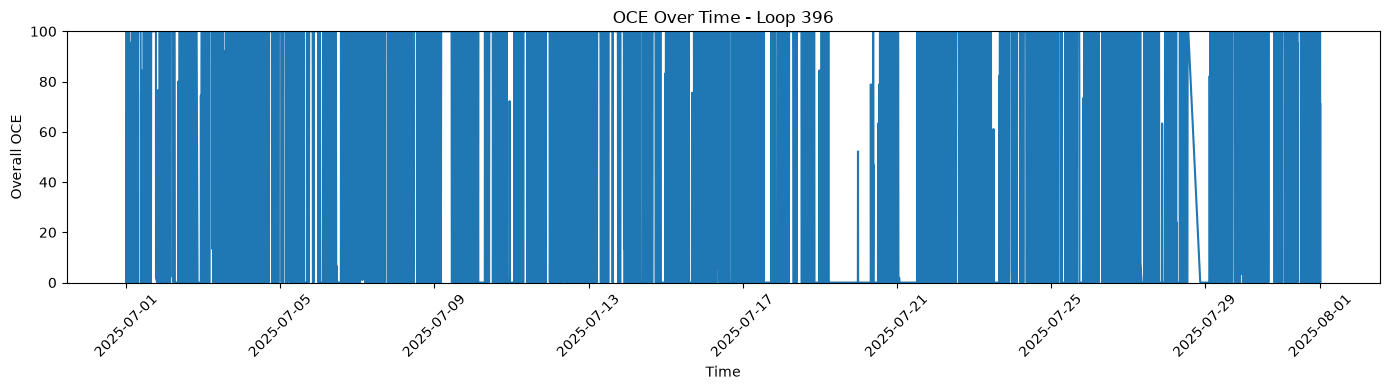

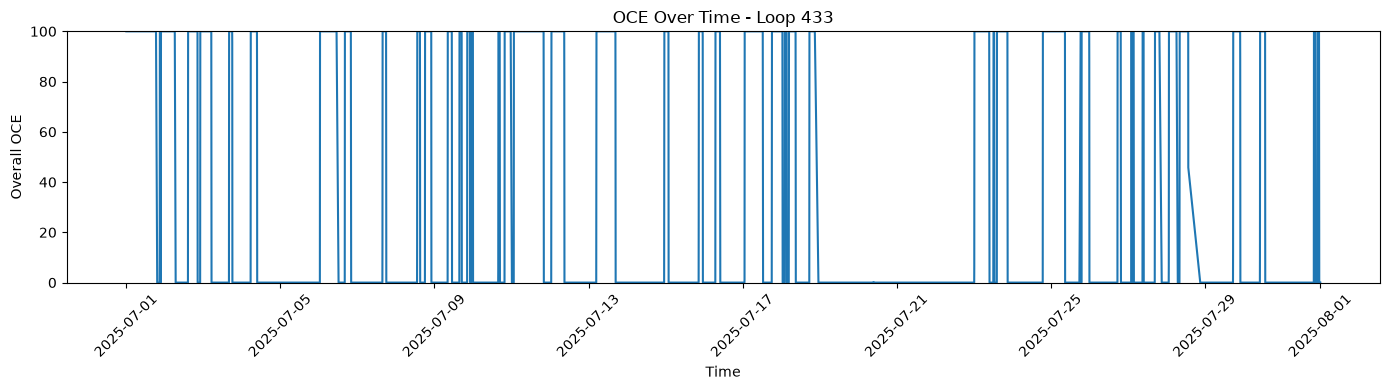

Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x0000022A053A0B80>
Traceback (most recent call last):
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\weakref.py", line 370, in remove
    self = selfref()
KeyboardInterrupt: 


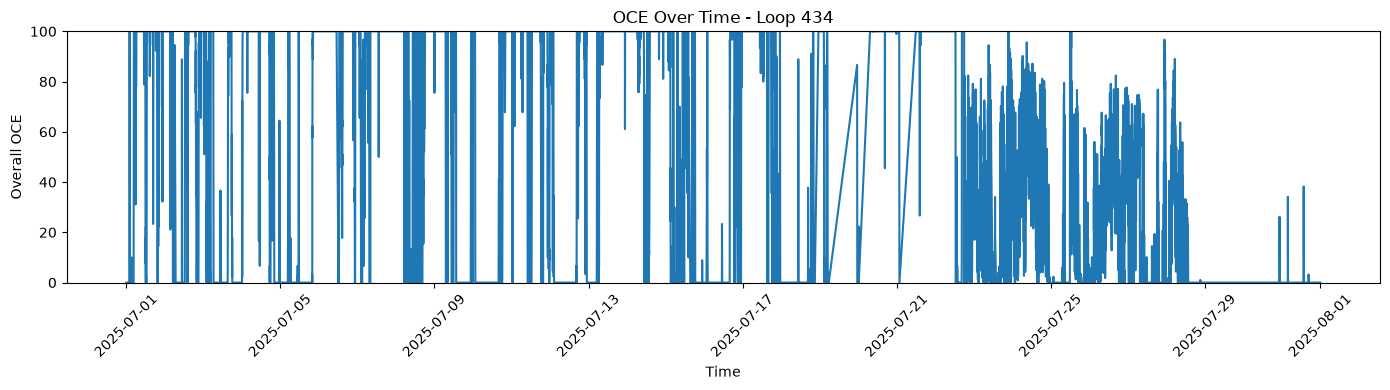

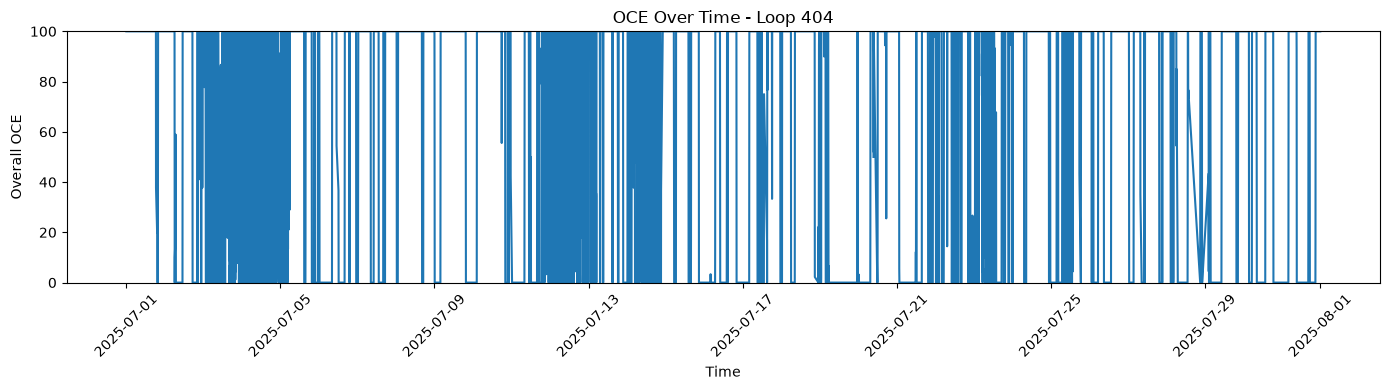

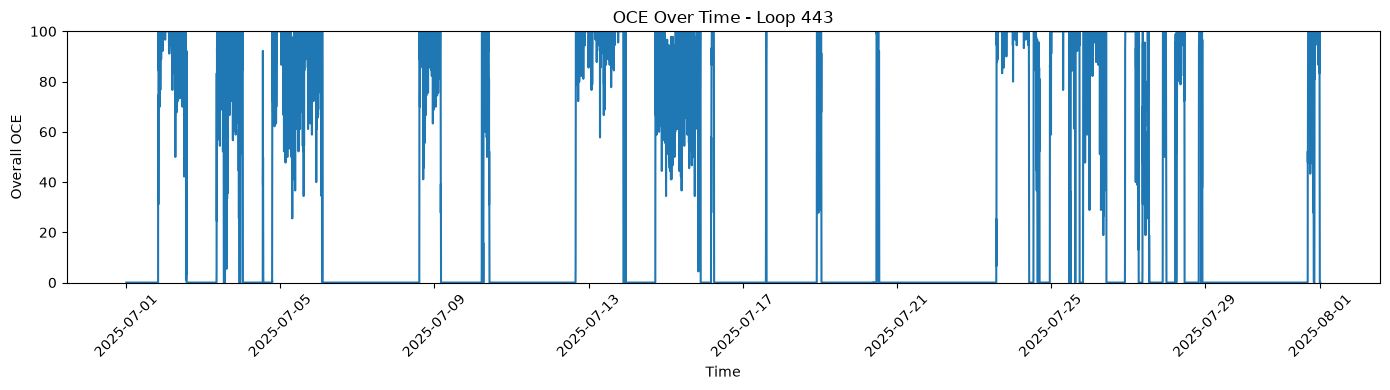

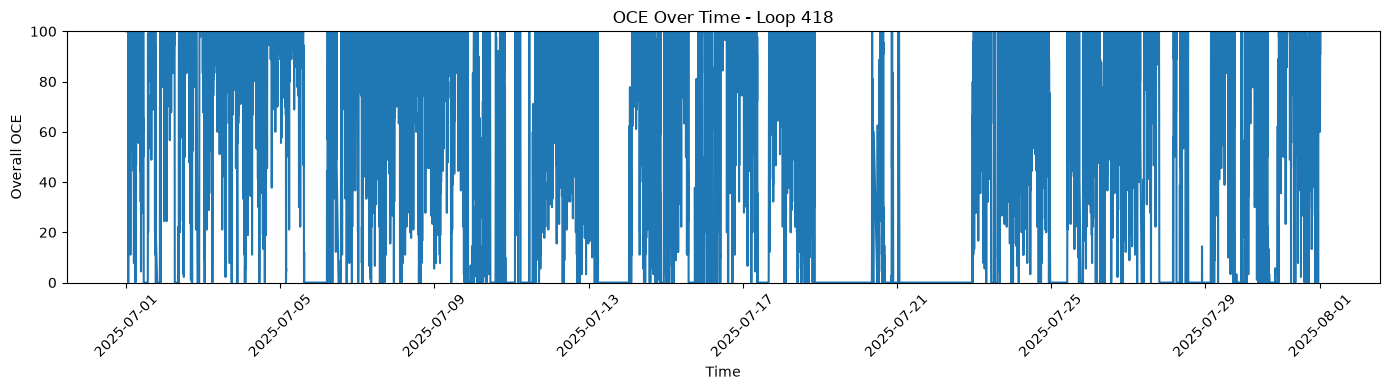

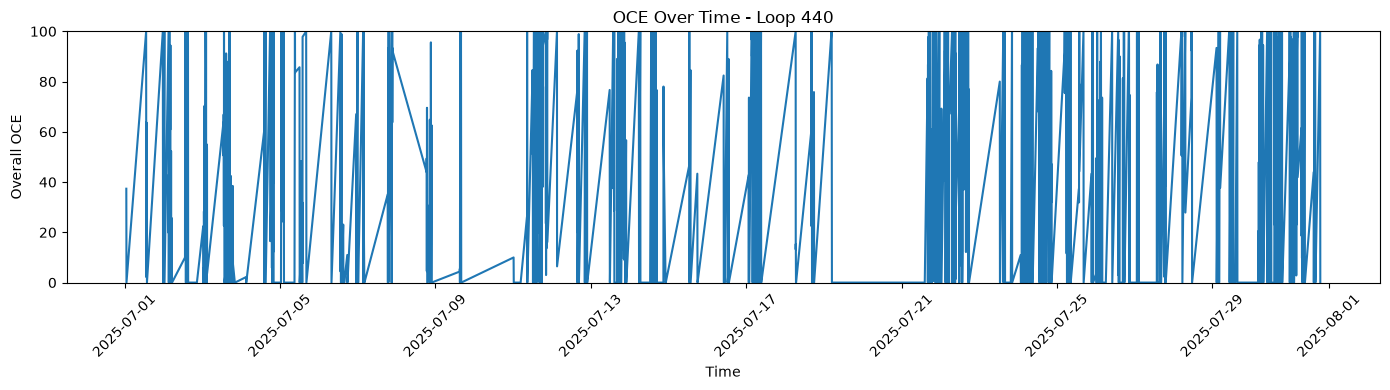

In [130]:
for loop_id in top_10_loops:

    loop_data = df[df["LoopId"] == loop_id].copy()
    loop_data = loop_data.sort_values("resulttime")

    plt.figure(figsize=(14, 4))

    plt.plot(
        loop_data["resulttime"],
        loop_data["OverallOCE"]
    )

    plt.title(f"OCE Over Time - Loop {loop_id}")
    plt.xlabel("Time")
    plt.ylabel("Overall OCE")
    plt.ylim(0, 100)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 3.3 Loop-Level OCE Analysis

In [ ]:
# ==========================================
# LOOP PERFORMANCE
# ==========================================

loop_summary = (
    df.groupby("LoopId")["OverallOCE"]
      .agg(
          Mean_OCE="mean",
          Median_OCE="median",
          Std_OCE="std",
          Observations="count"
      )
      .reset_index()
)

loop_summary.head()

,LoopId,Mean_OCE,Median_OCE,Std_OCE,Observations
0,5,51.669211,50.0,27.267471,14879
1,6,84.714066,100.0,35.909723,13606
2,293,80.854033,100.0,35.771695,12421
3,294,0.000000,0.0,0.000000,11
4,295,0.000000,0.0,0.000000,11


In [124]:
loop_summary = loop_summary.sort_values(
    "Mean_OCE",
    ascending=True
)

loop_summary

,LoopId,Mean_OCE,Median_OCE,Std_OCE,Observations
3,294,0.000000,0.0,0.000000,11
4,295,0.000000,0.0,0.000000,11
15,395,0.000000,0.0,0.000000,13606
30,410,0.000000,0.0,0.000000,13606
51,437,0.000000,0.0,0.000000,13606
...,...,...,...,...,...
9,300,93.237821,100.0,24.466523,13731
93,699,95.044012,100.0,20.737739,14113
7,298,95.192994,100.0,21.142129,13053
92,698,97.530596,100.0,14.301546,13816


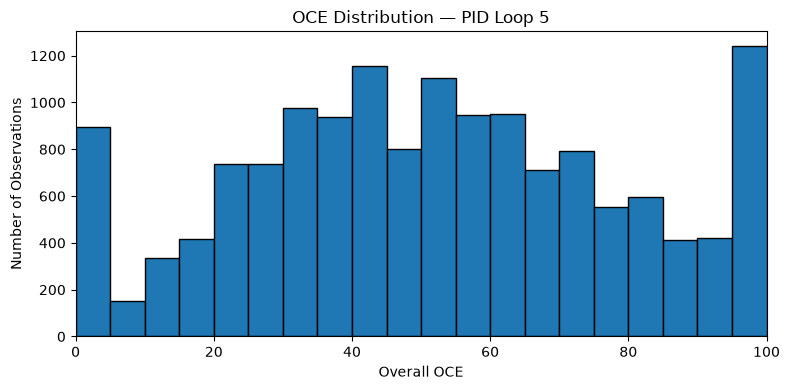

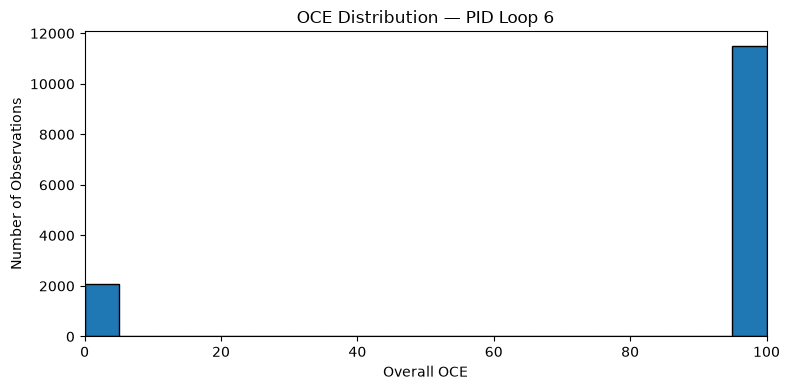

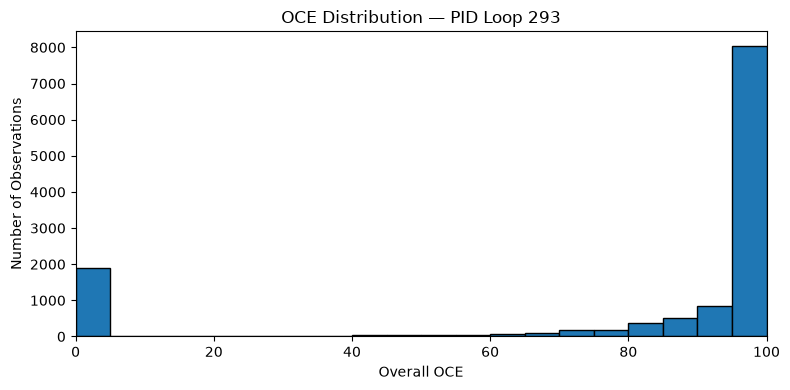

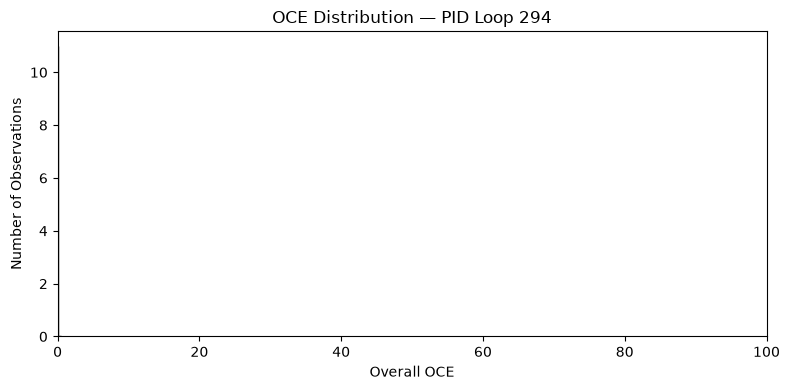

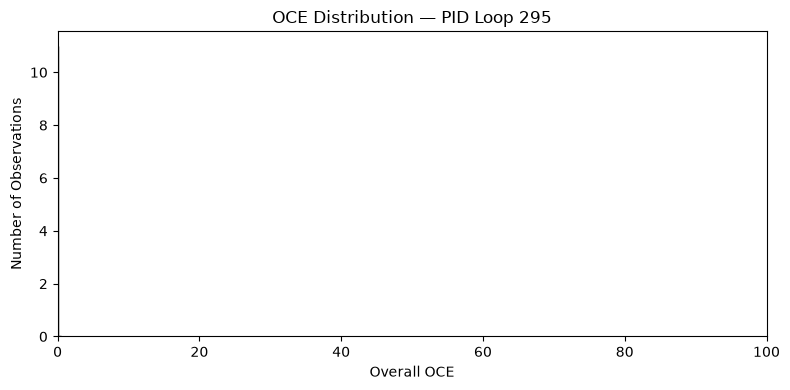

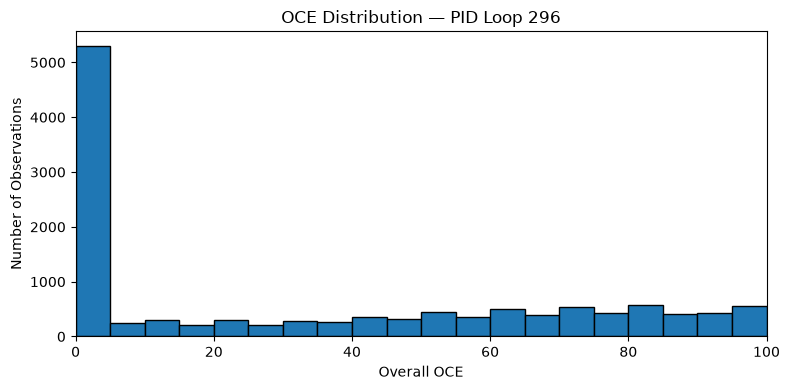

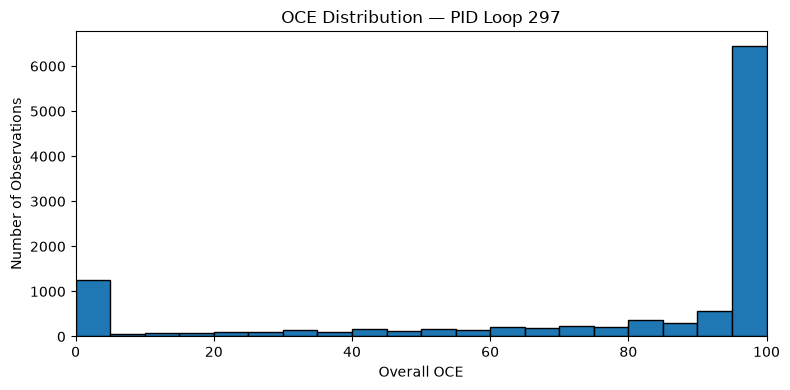

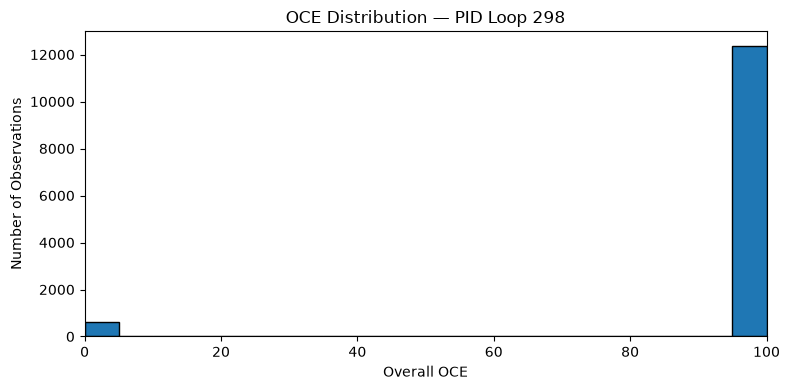

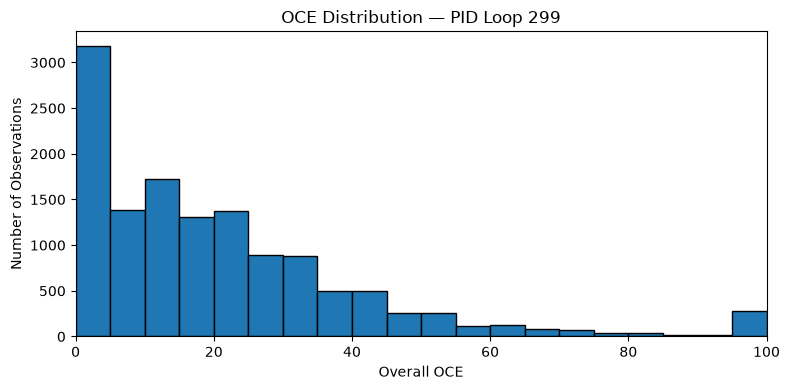

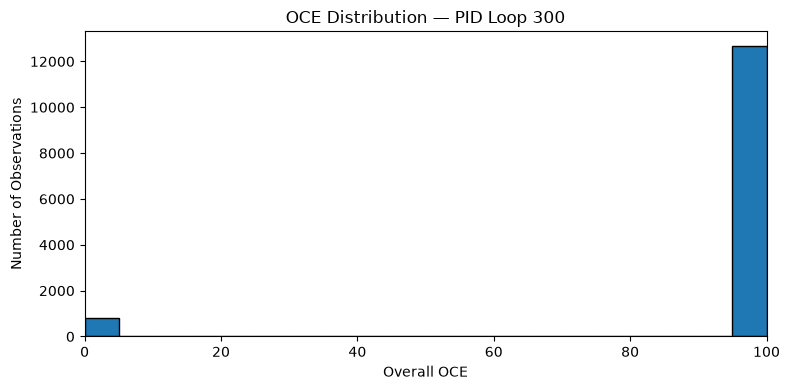

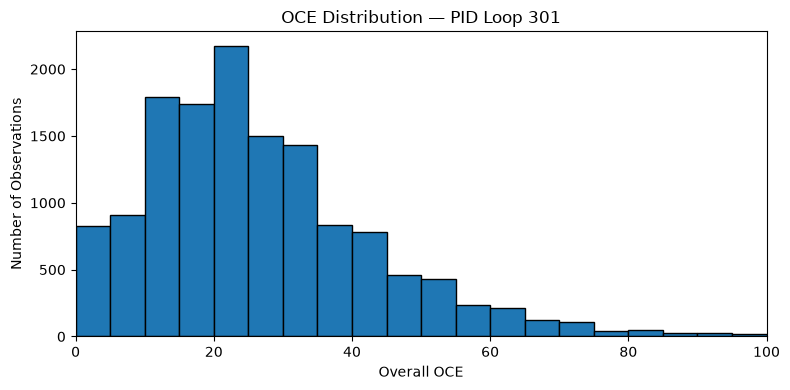

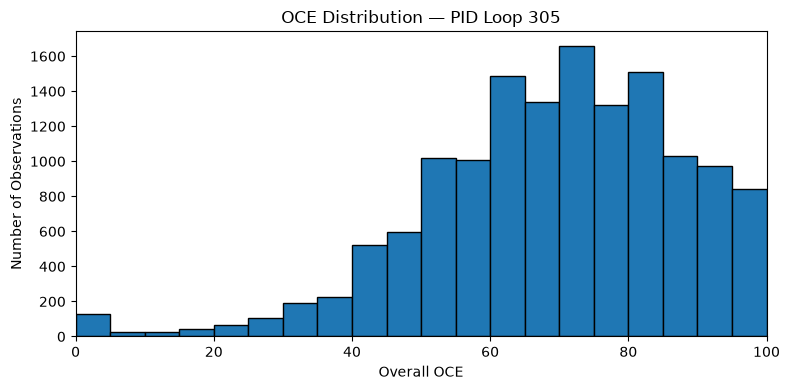

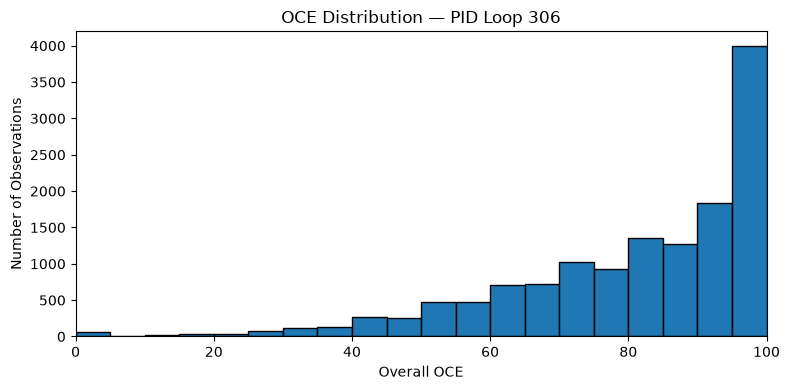

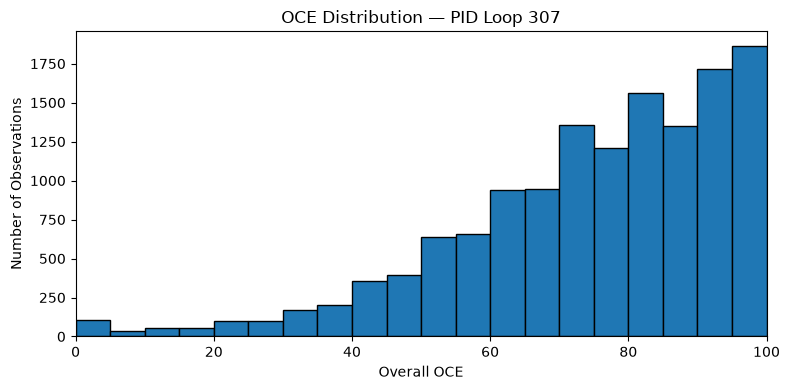

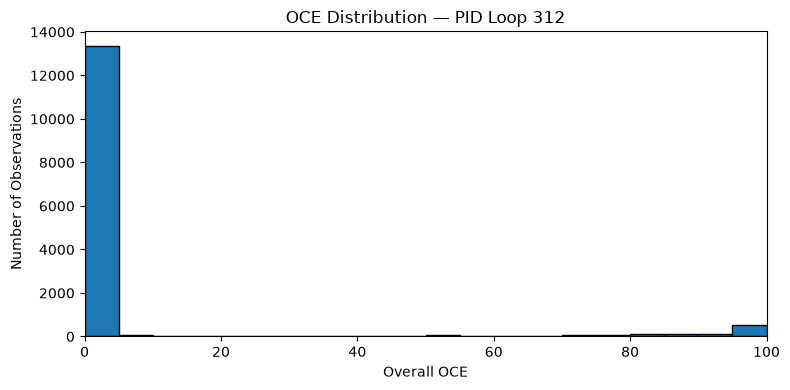

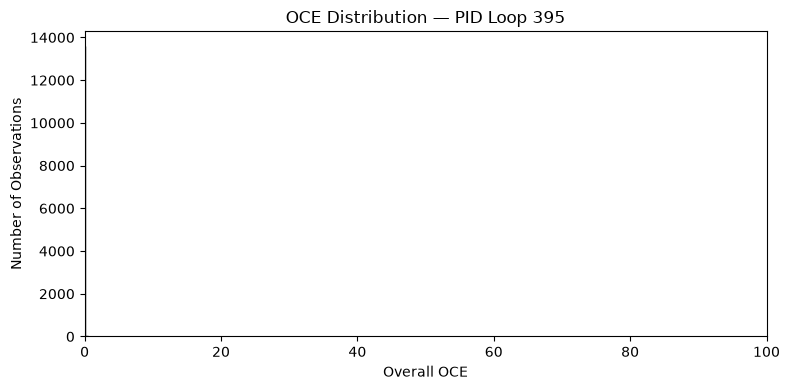

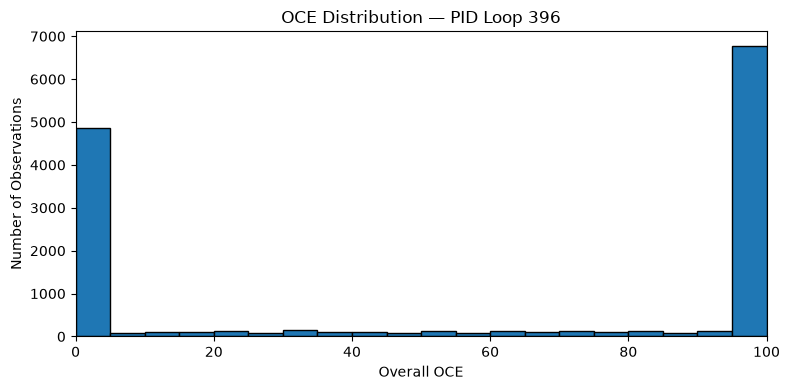

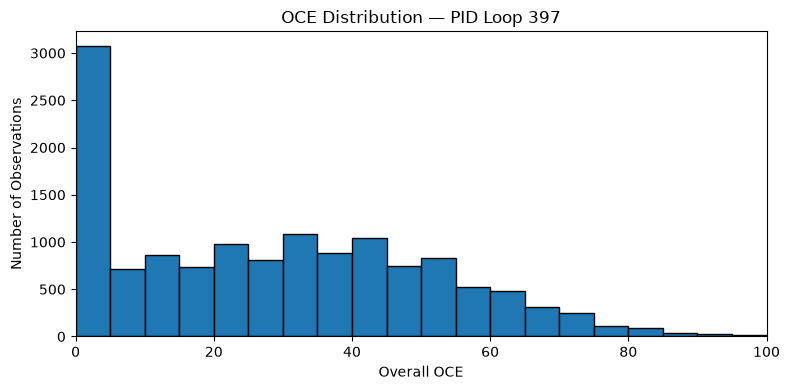

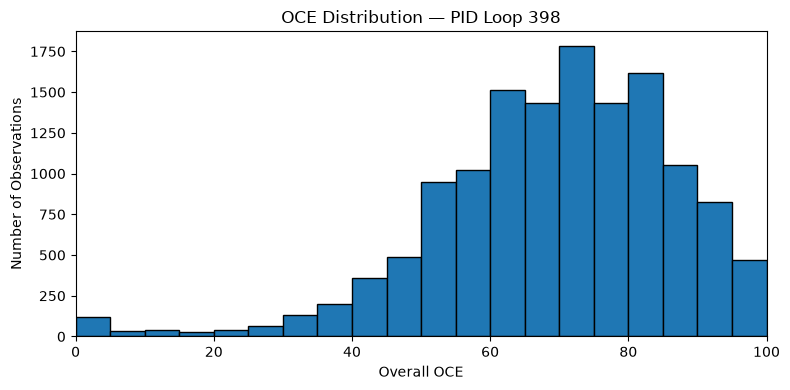

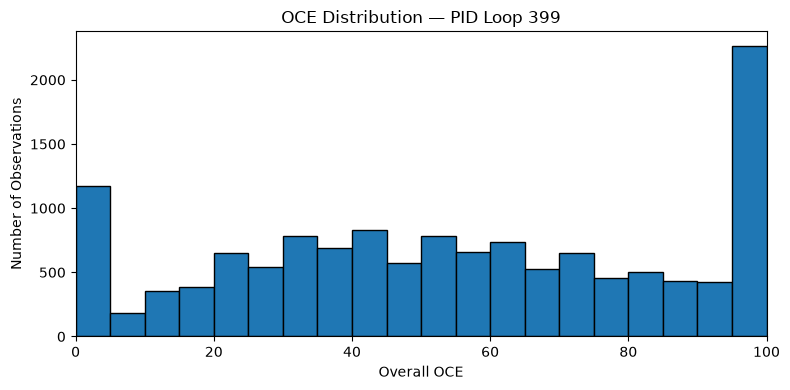

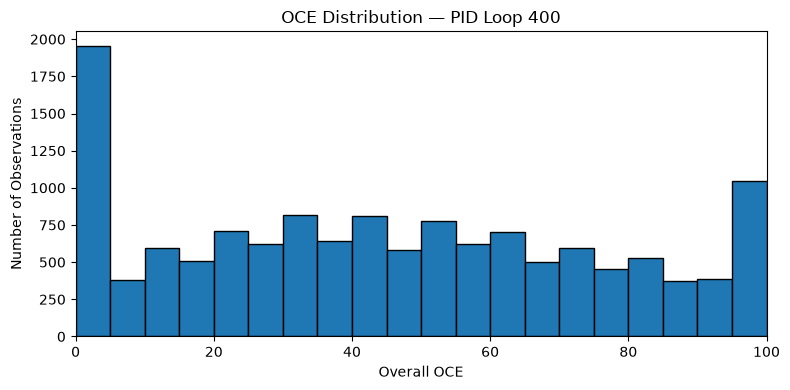

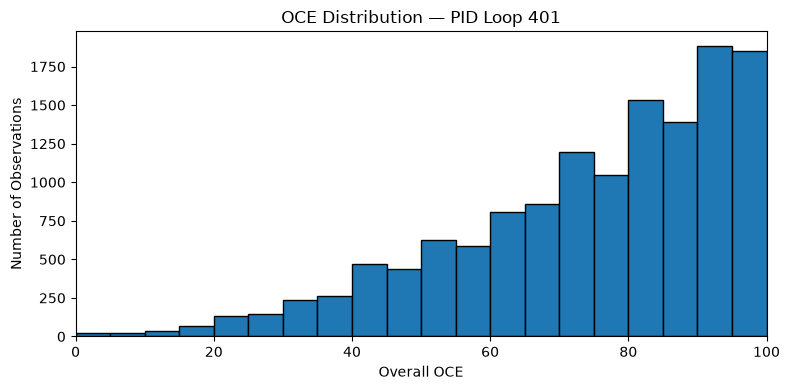

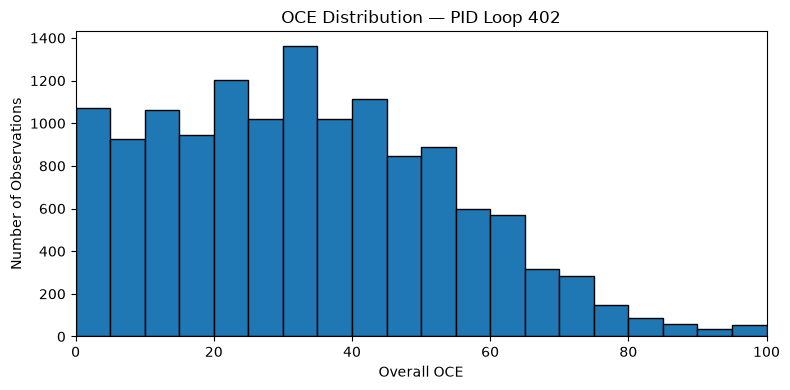

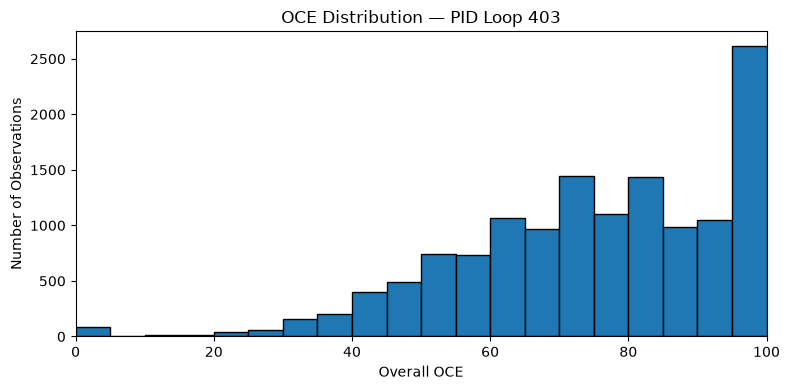

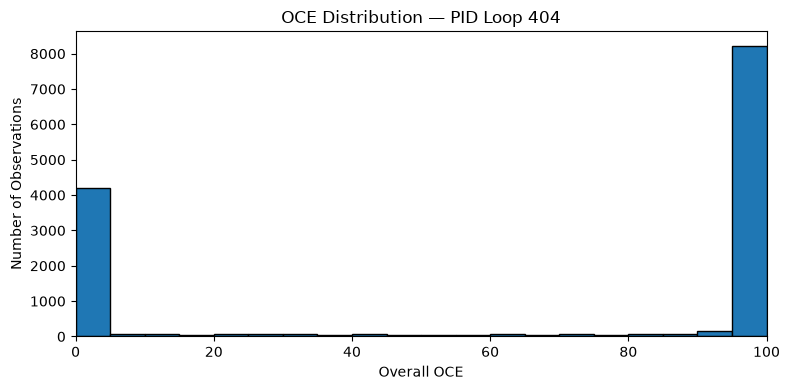

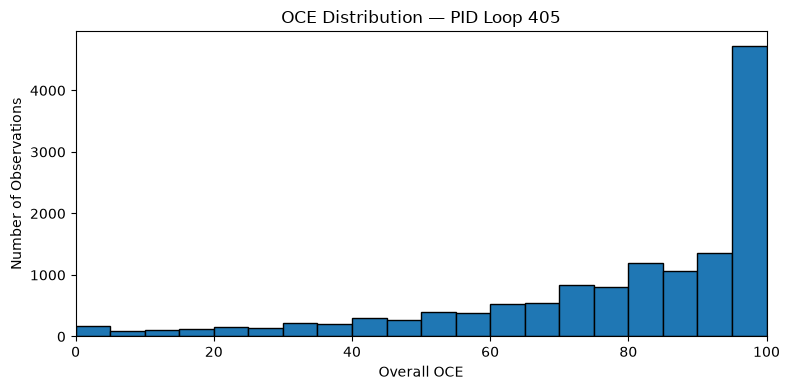

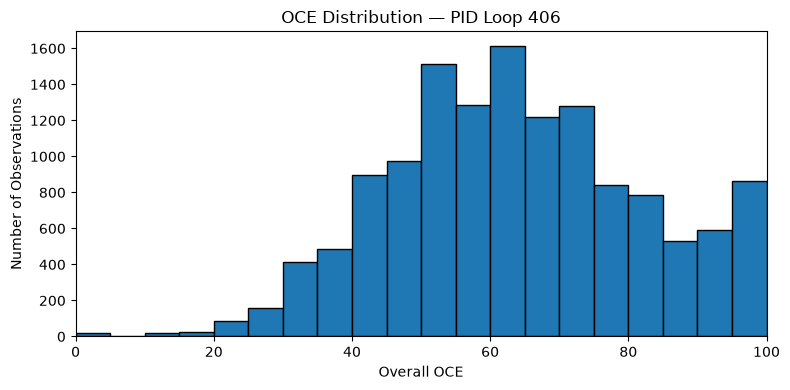

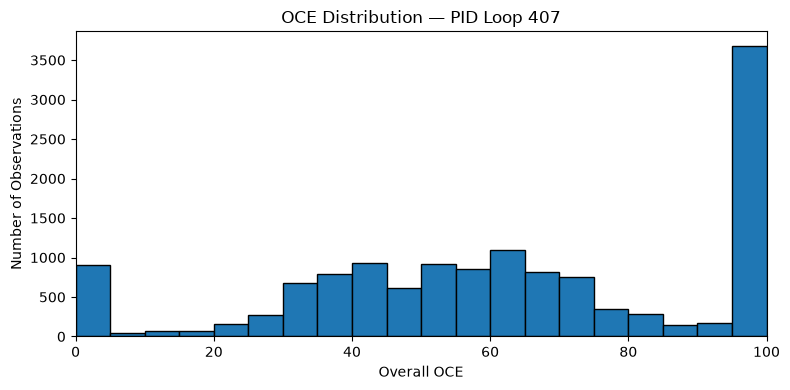

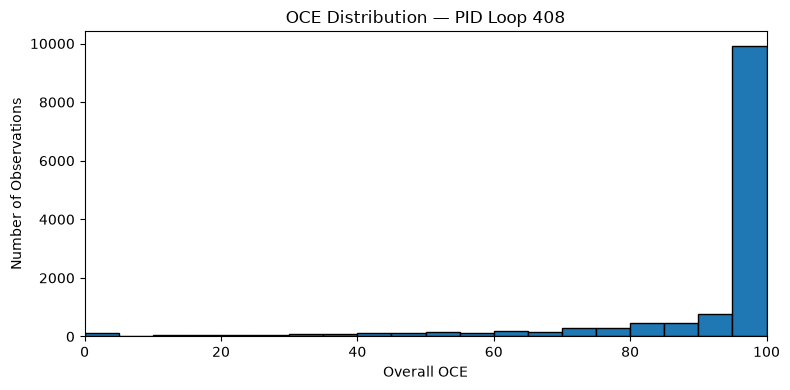

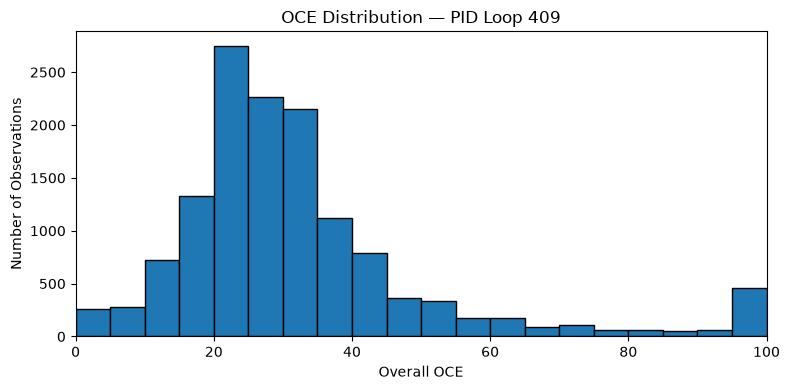

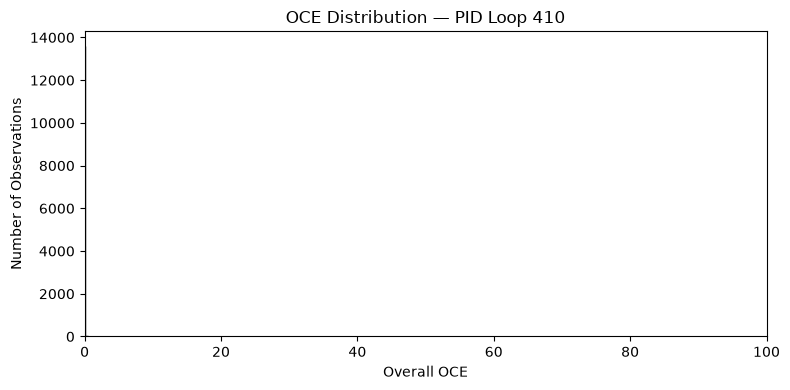

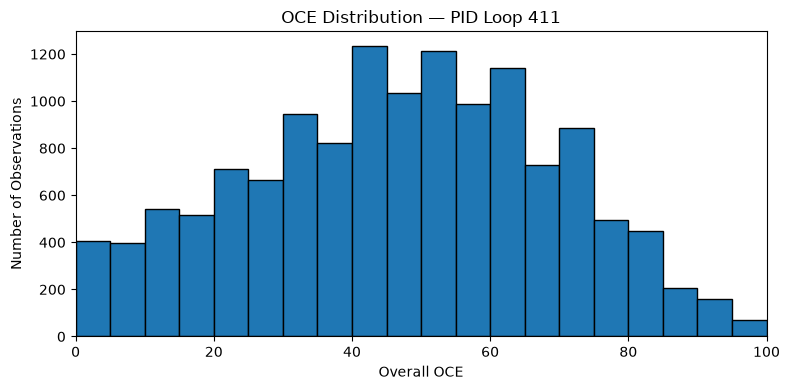

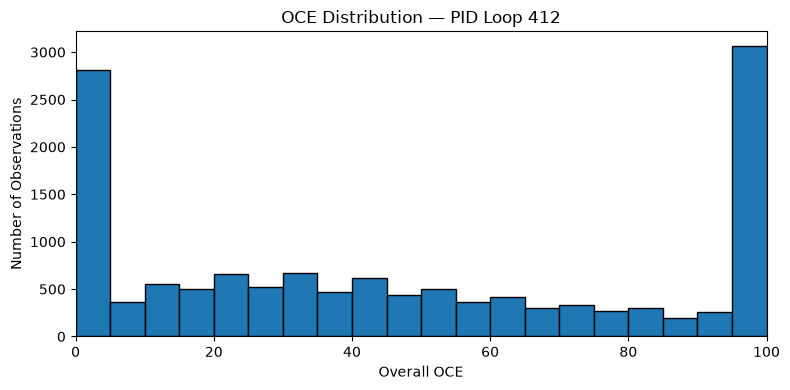

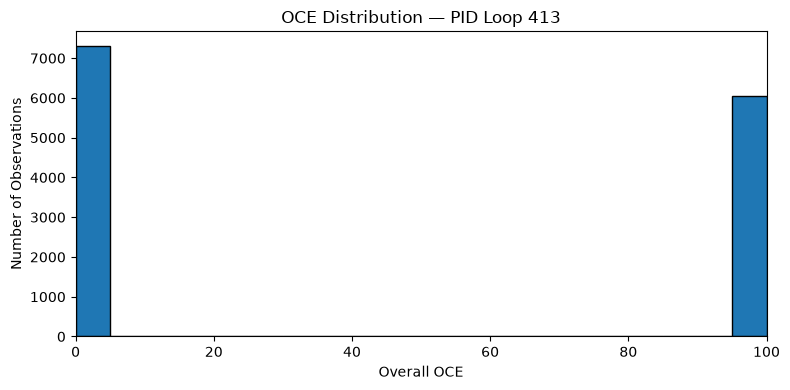

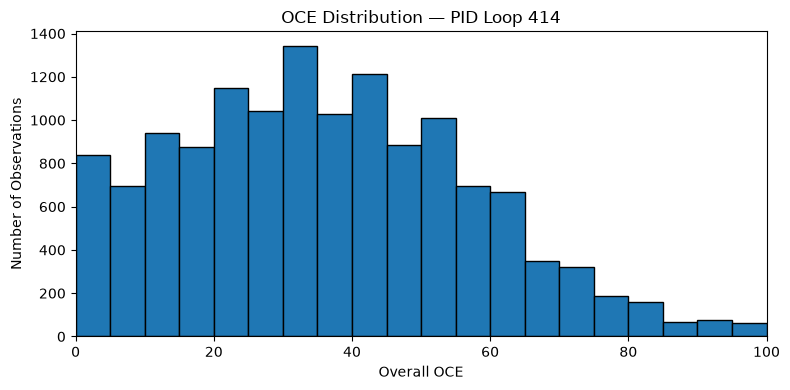

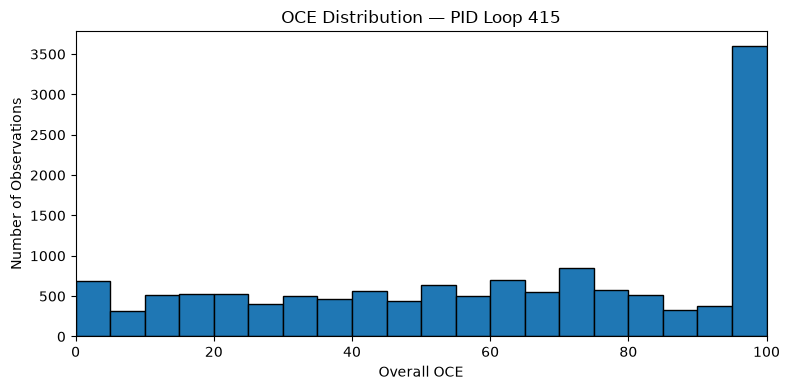

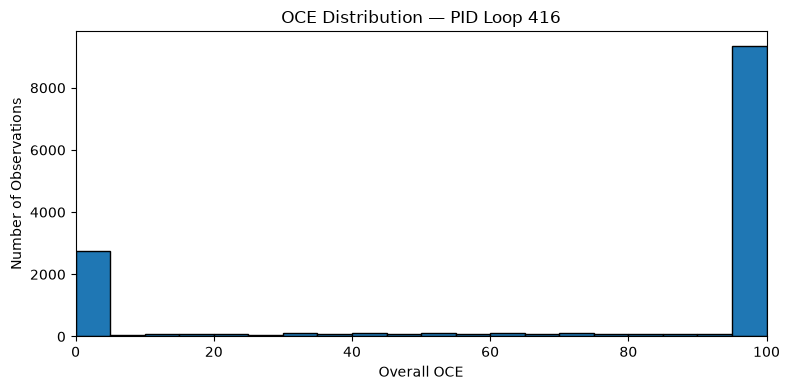

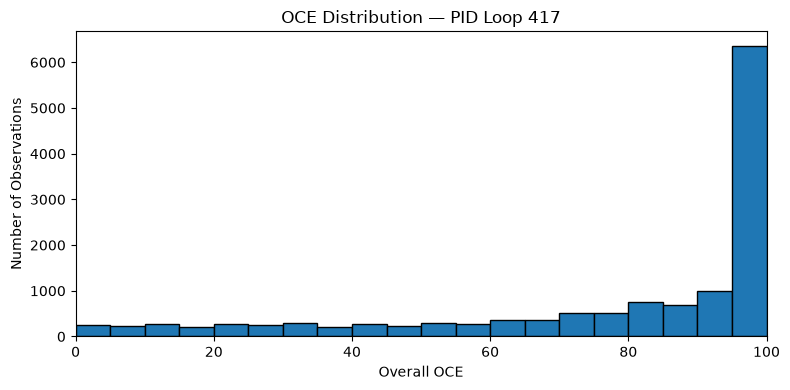

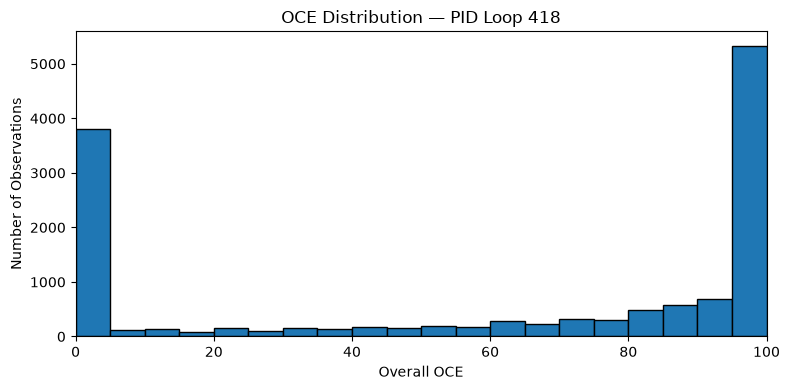

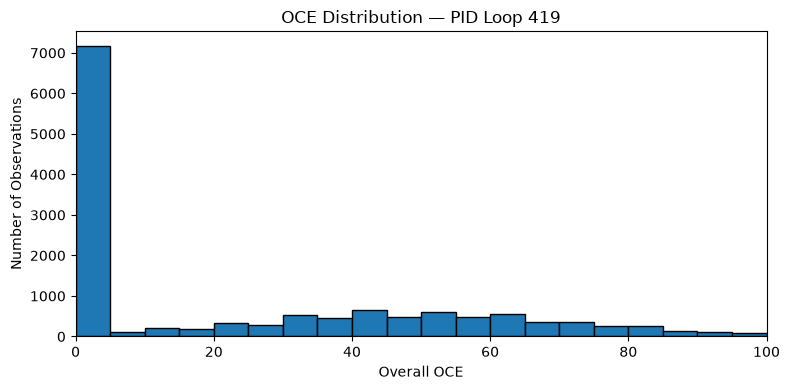

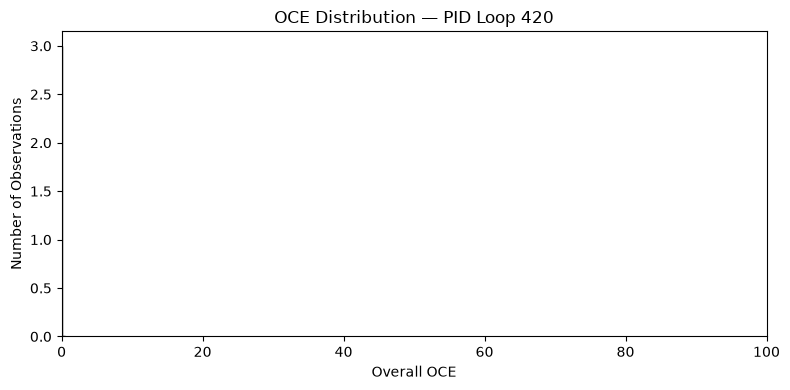

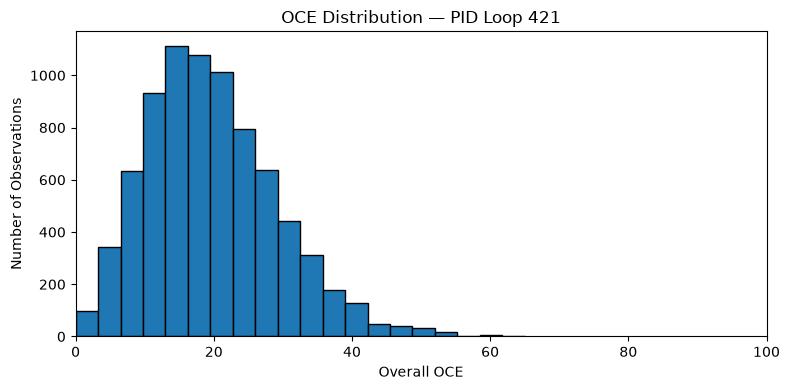

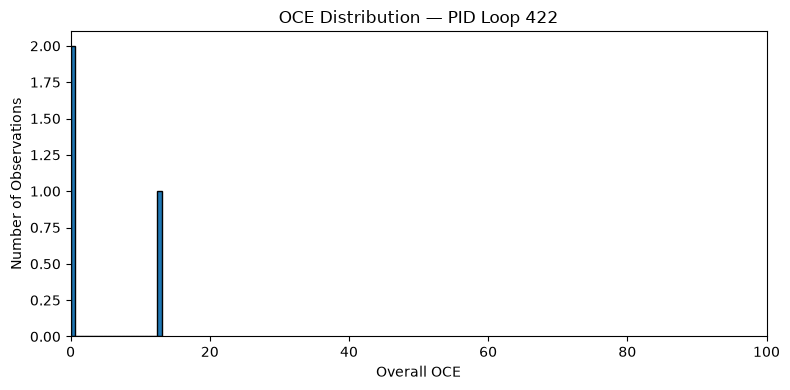

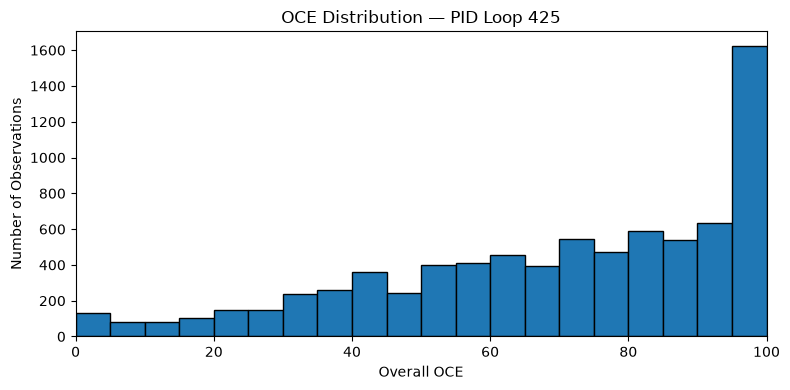

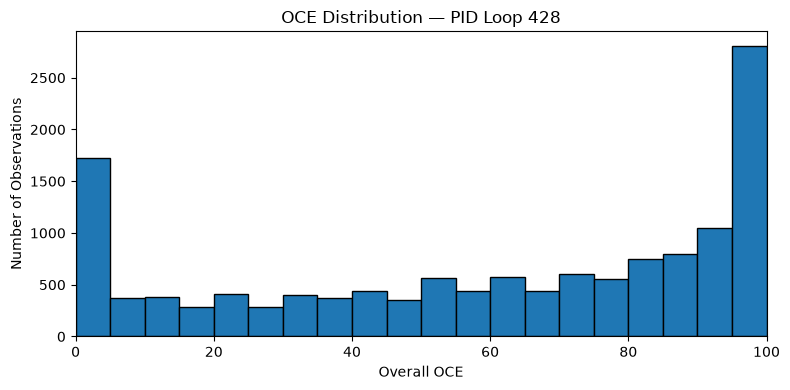

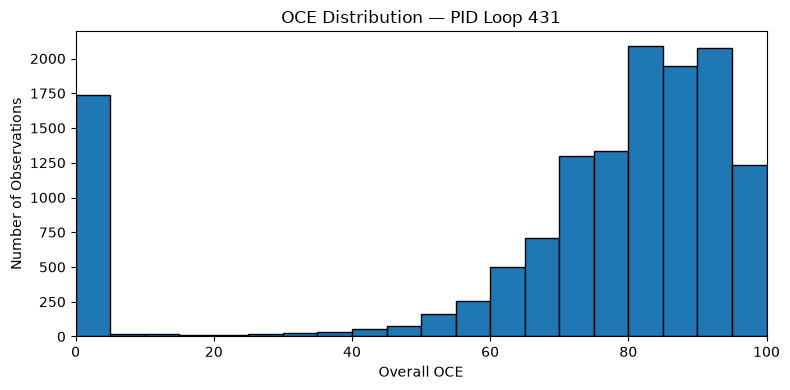

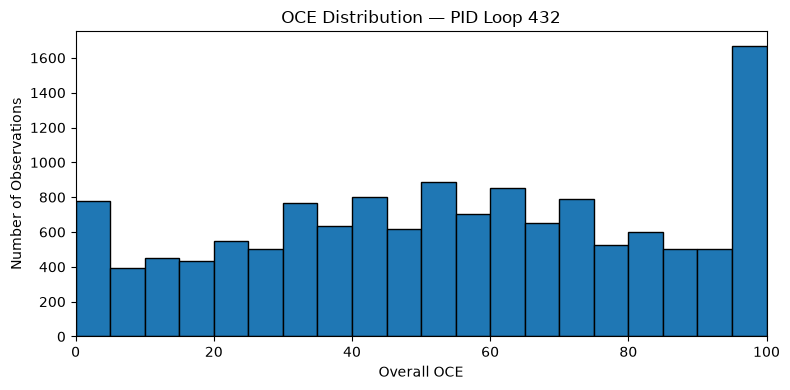

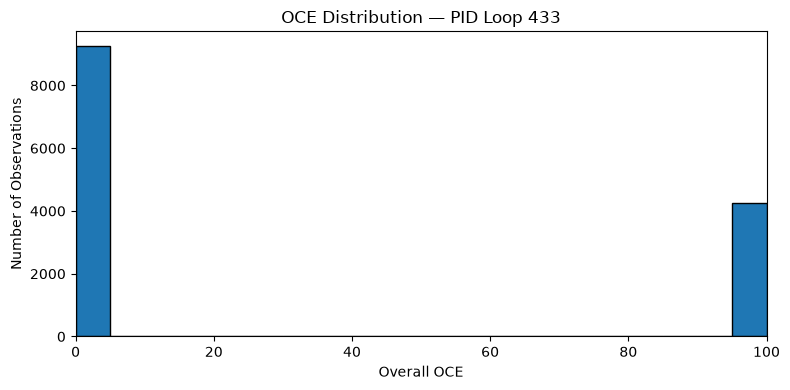

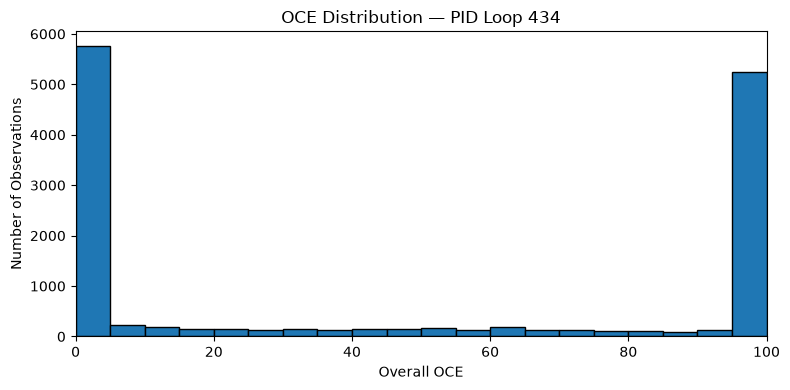

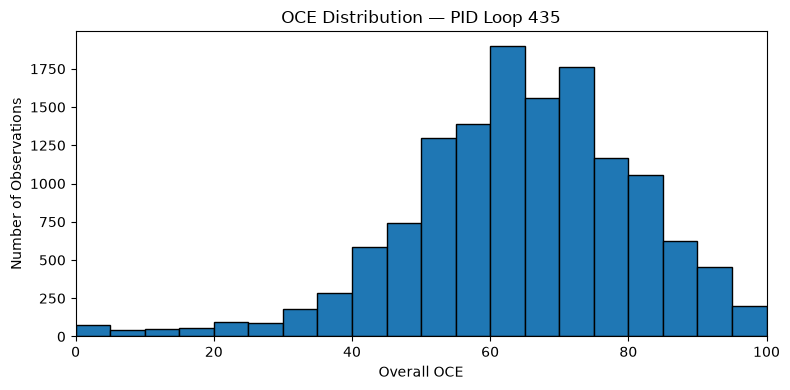

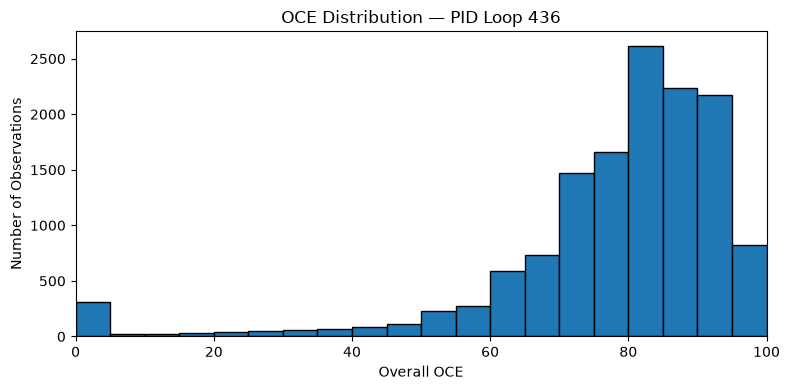

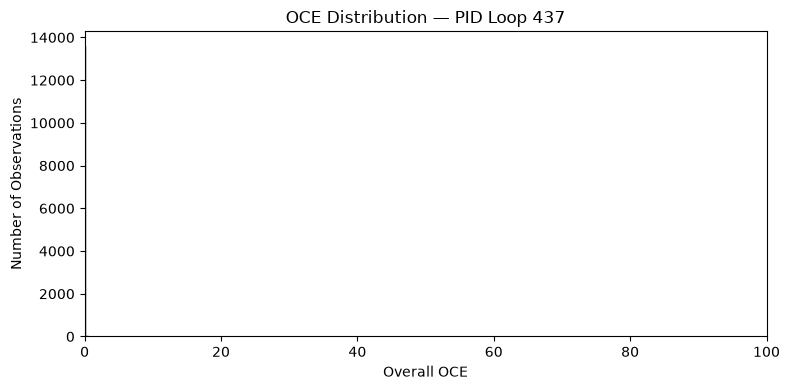

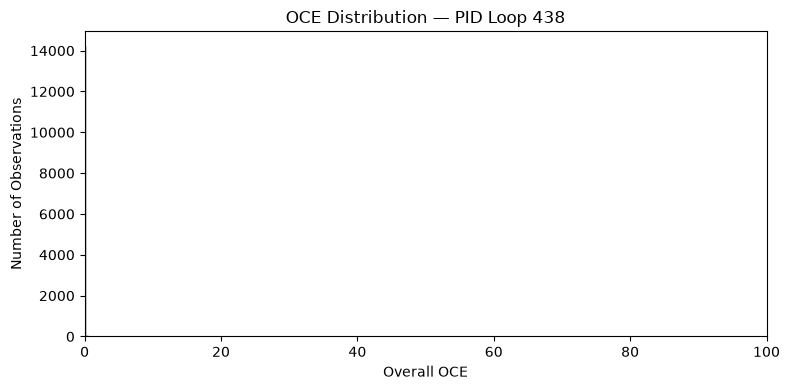

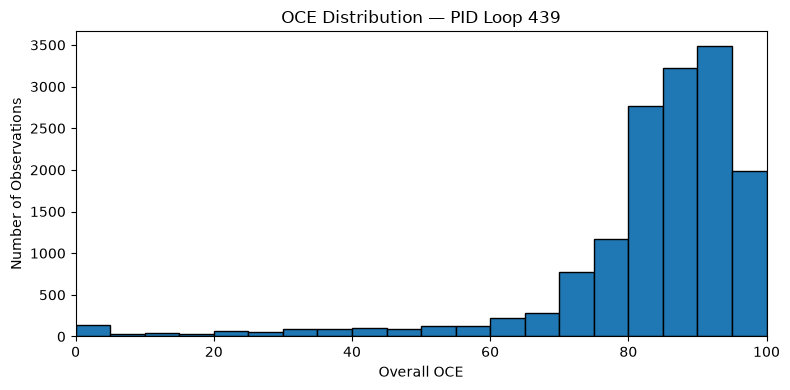

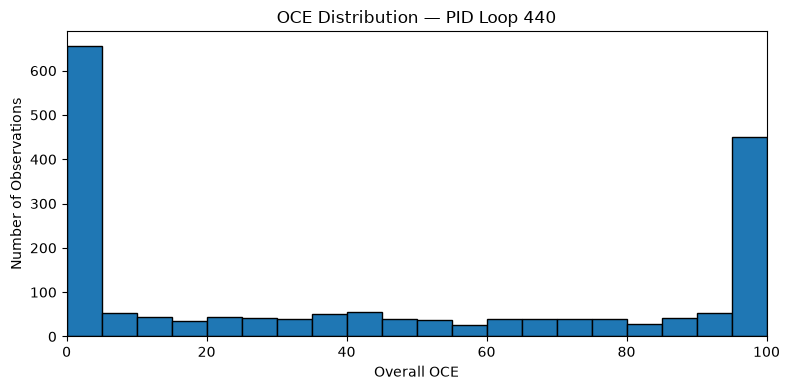

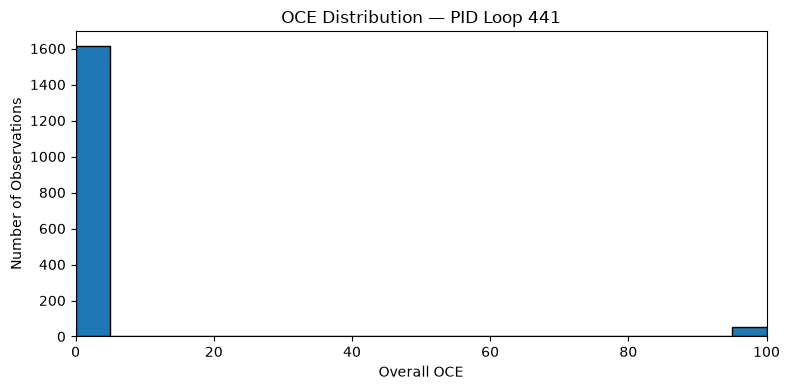

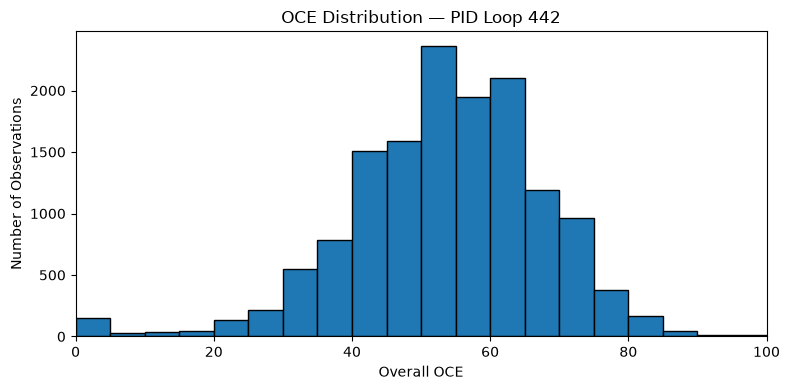

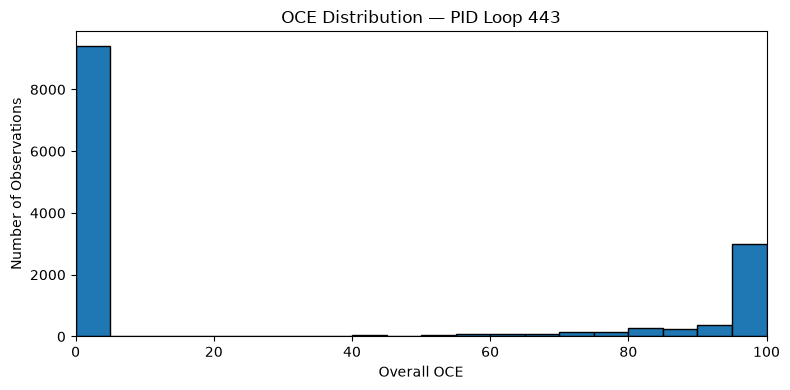

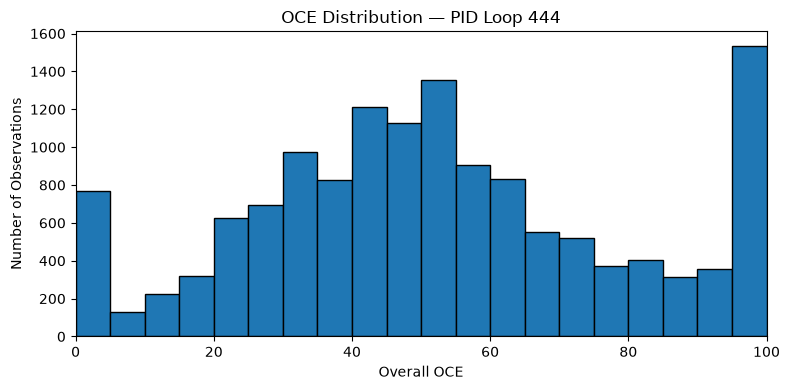

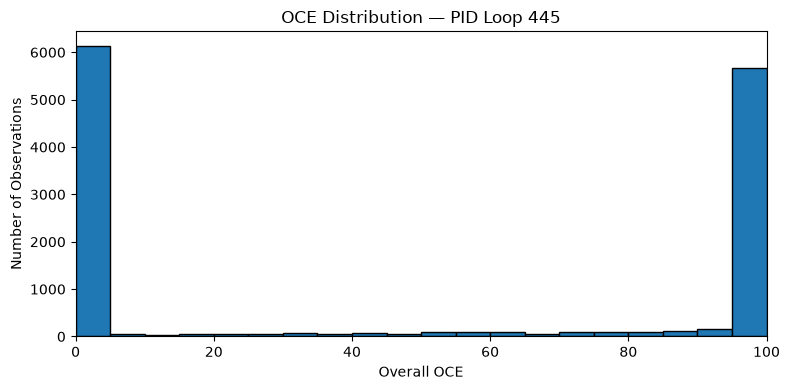

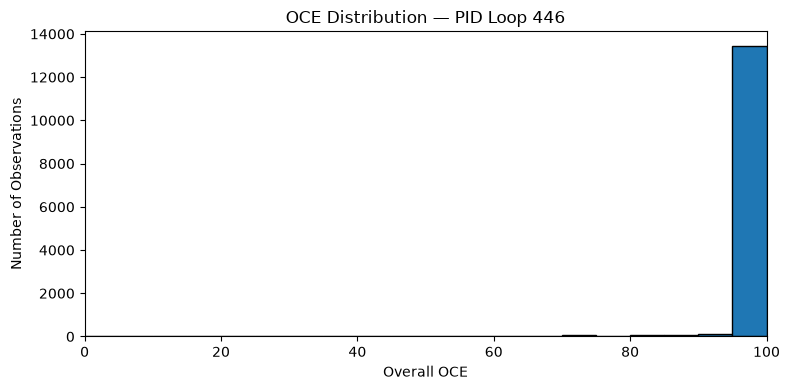

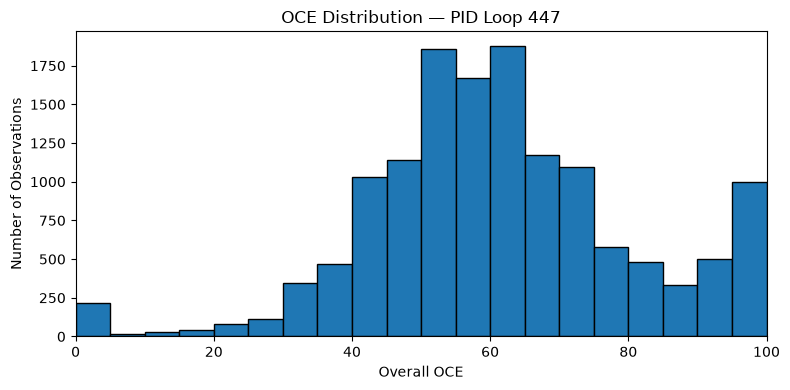

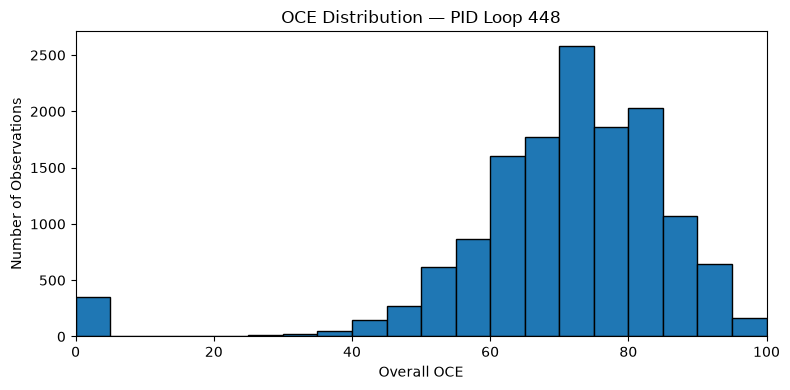

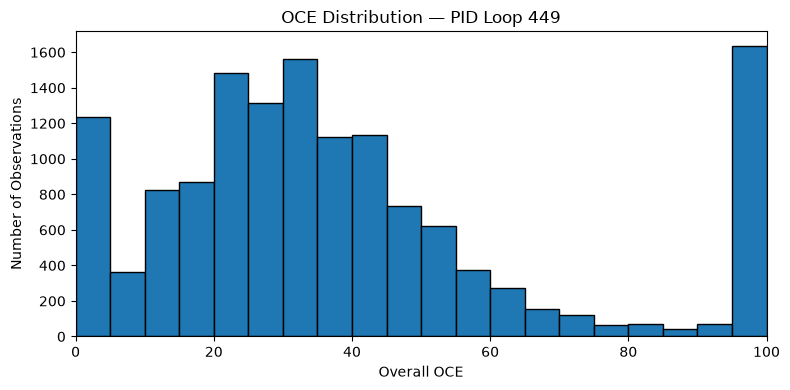

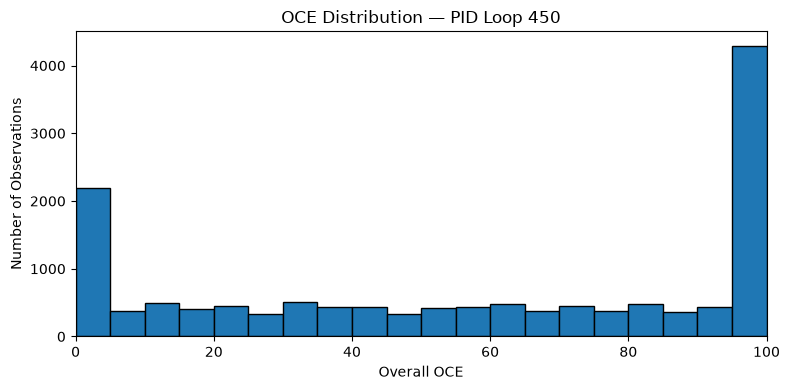

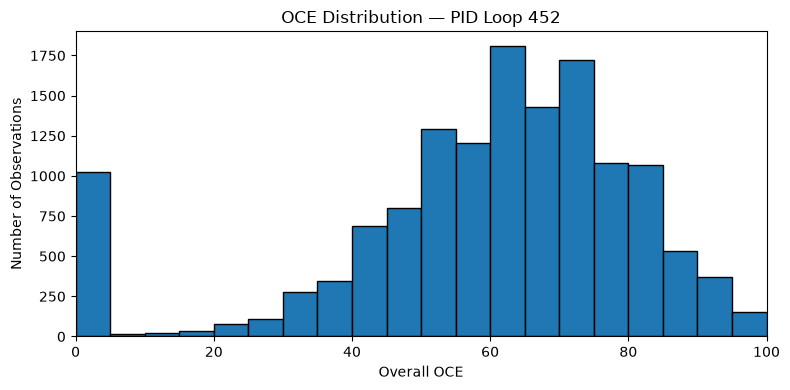

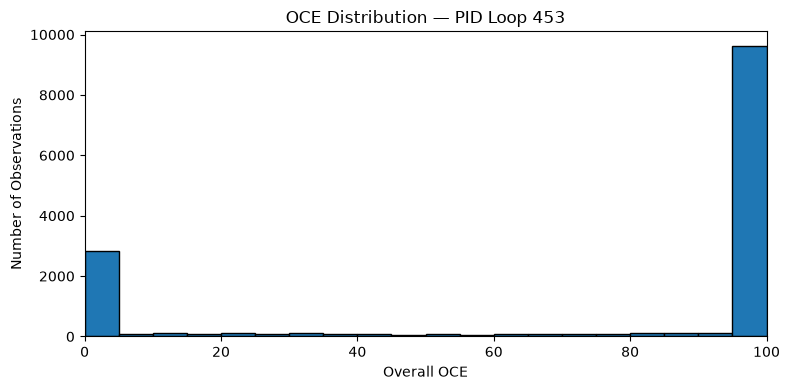

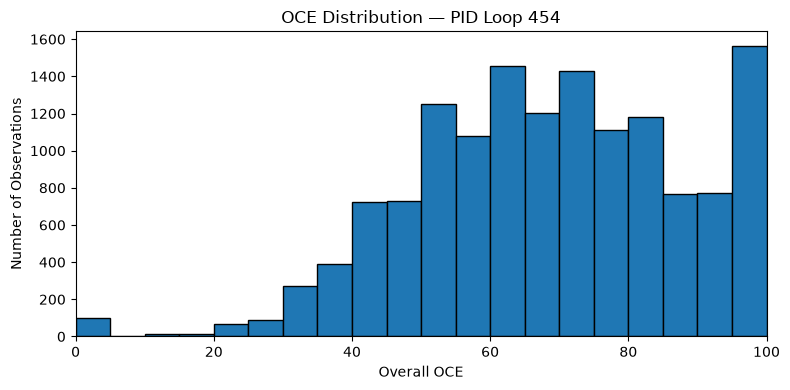

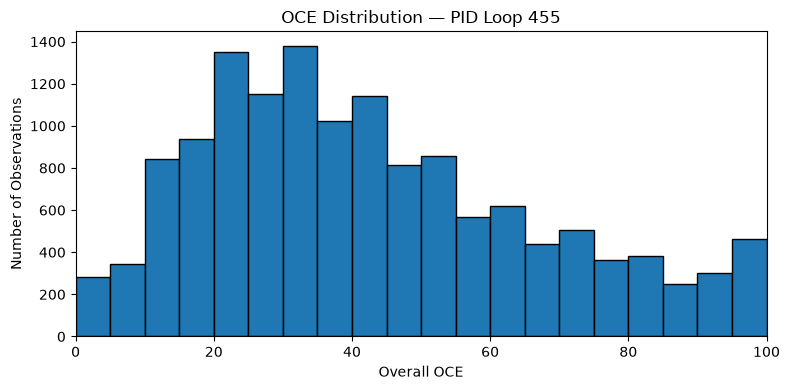

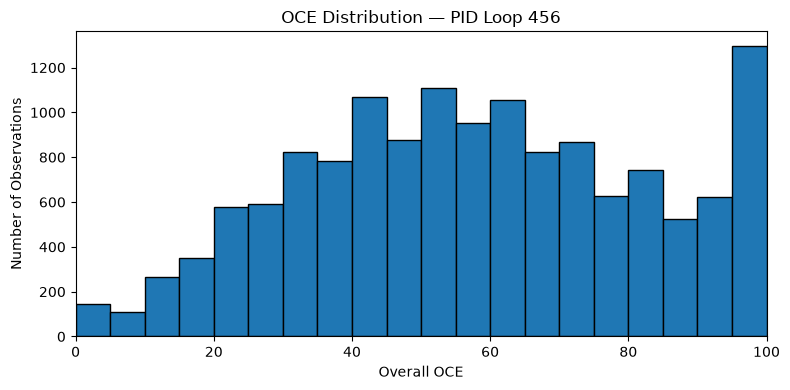

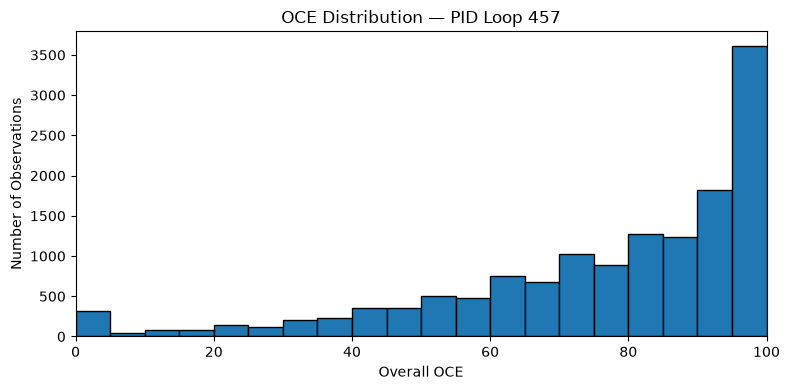

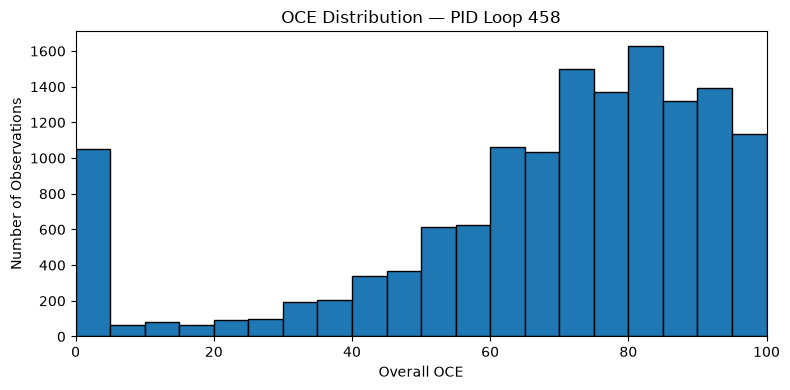

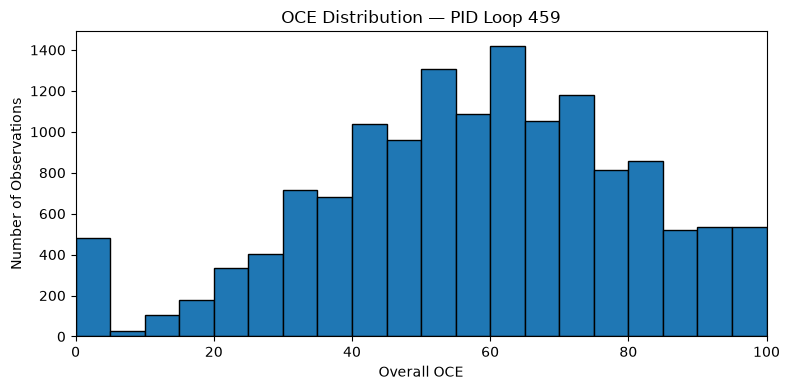

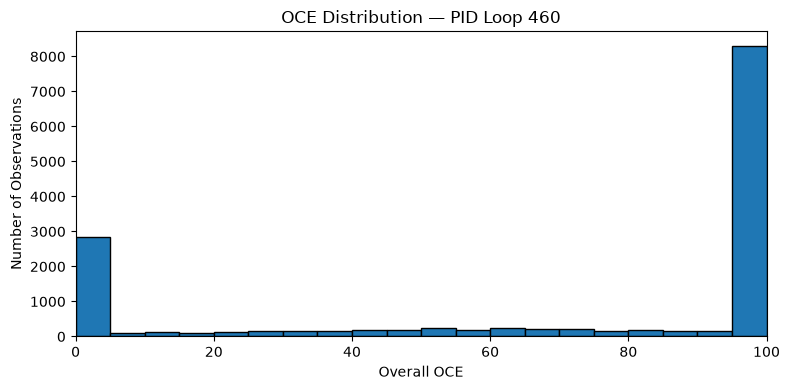

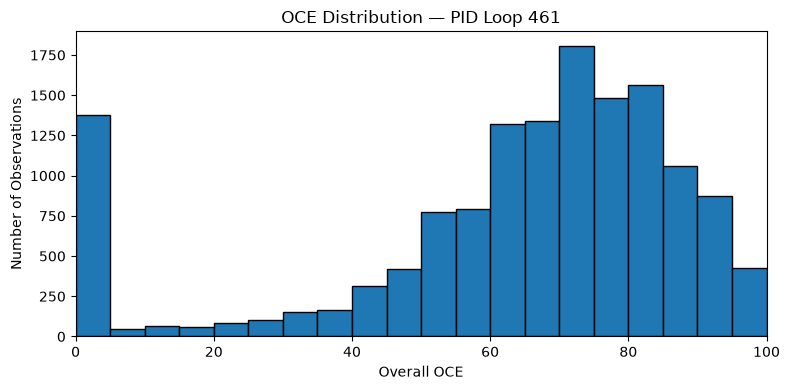

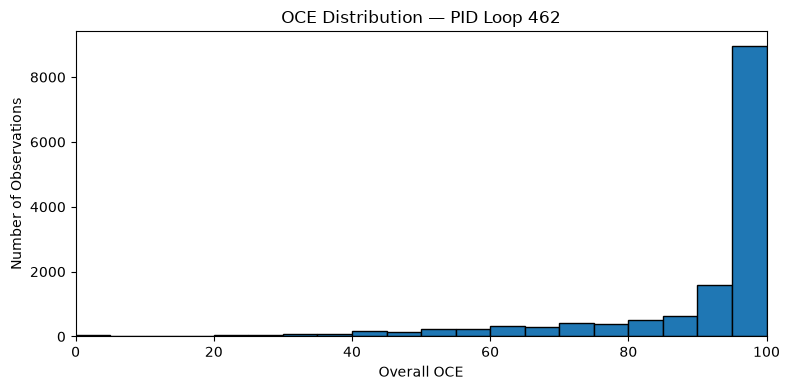

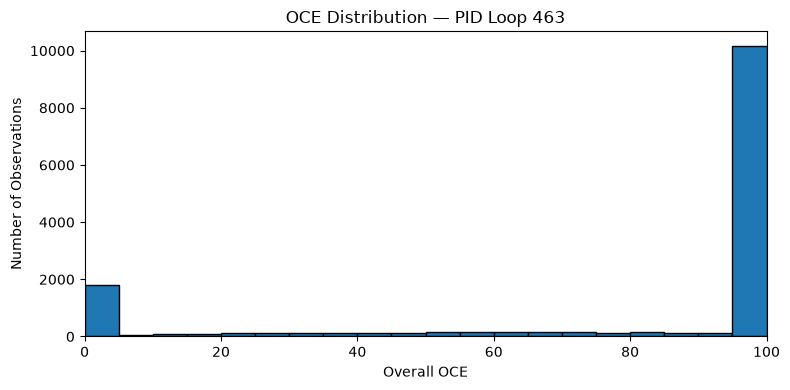

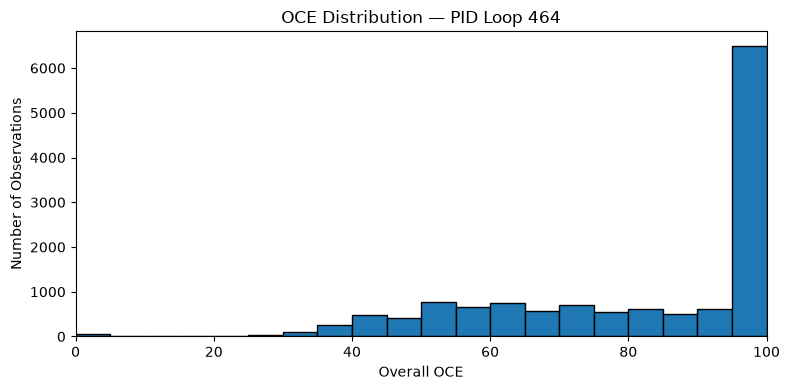

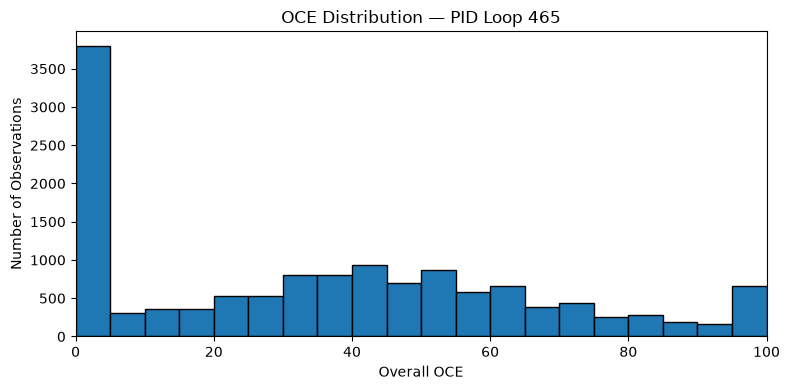

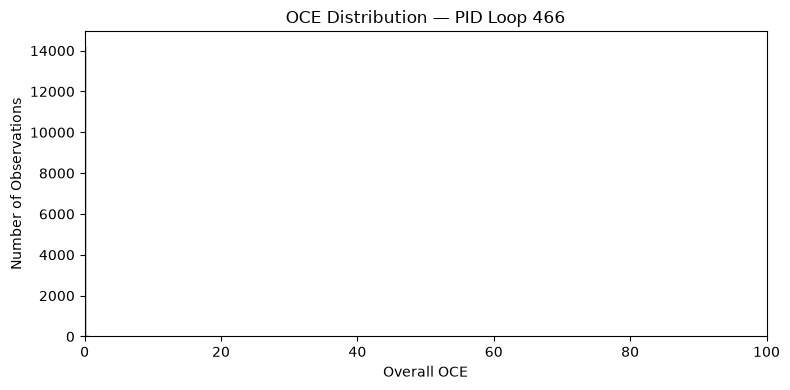

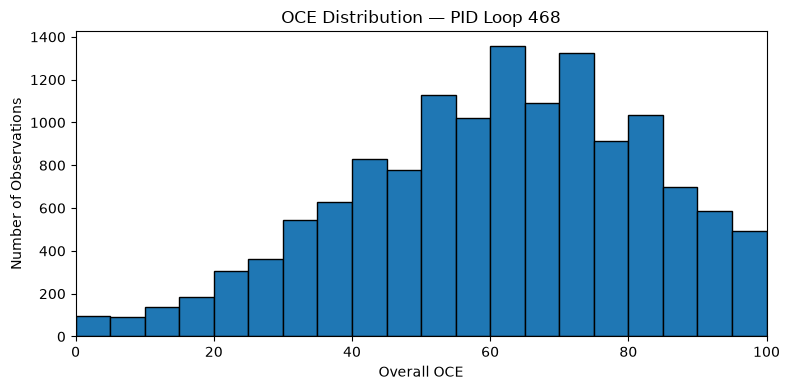

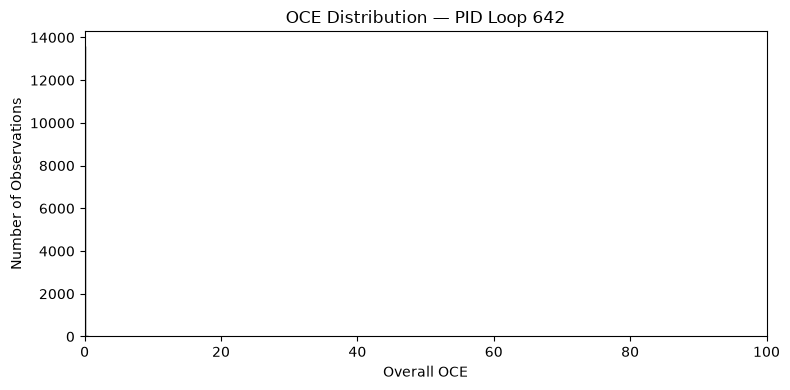

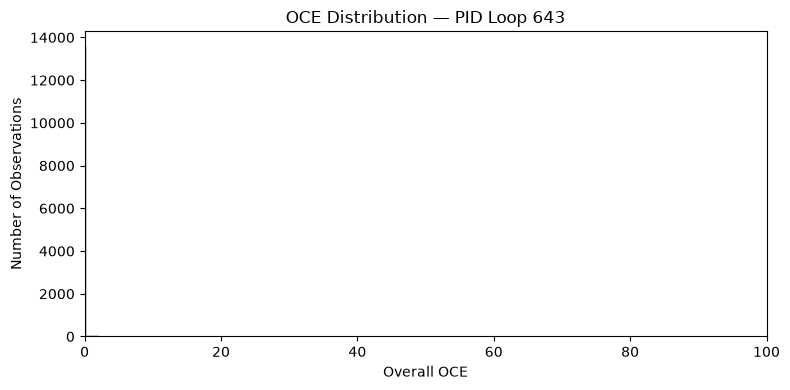

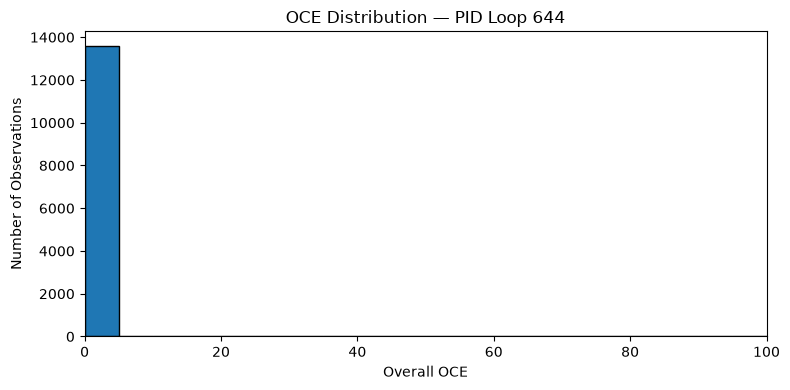

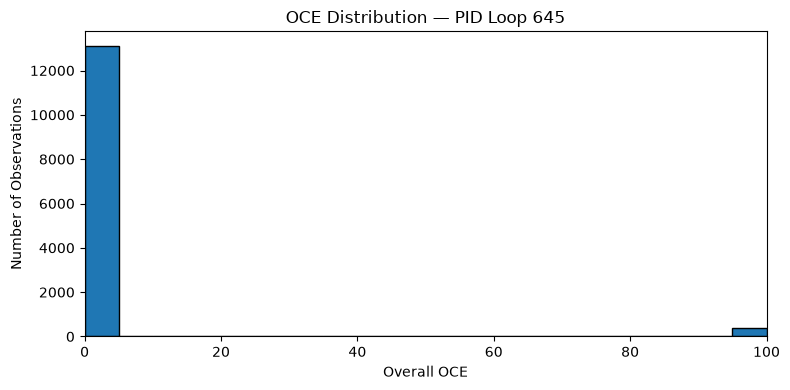

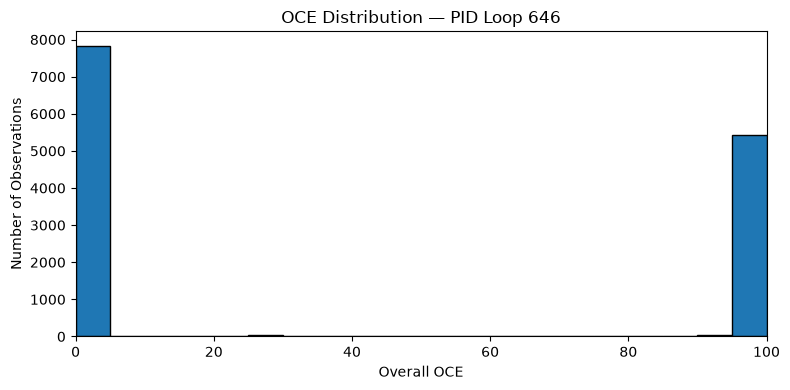

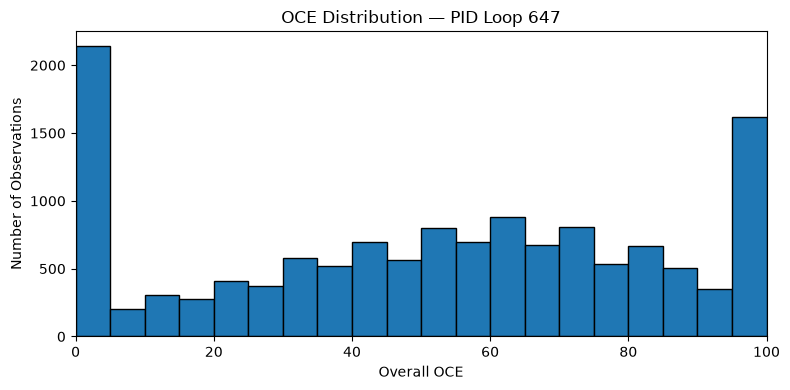

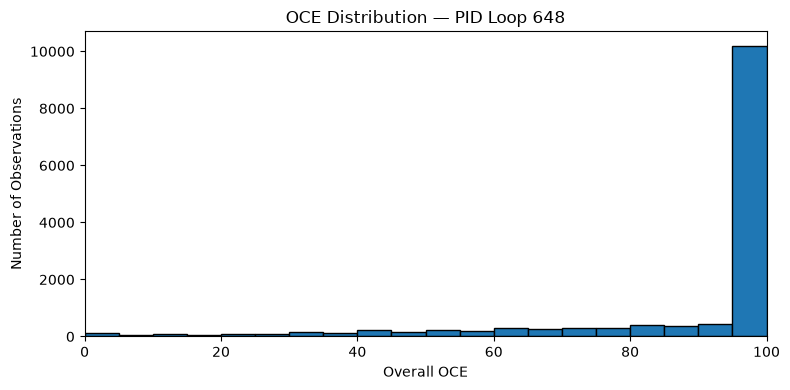

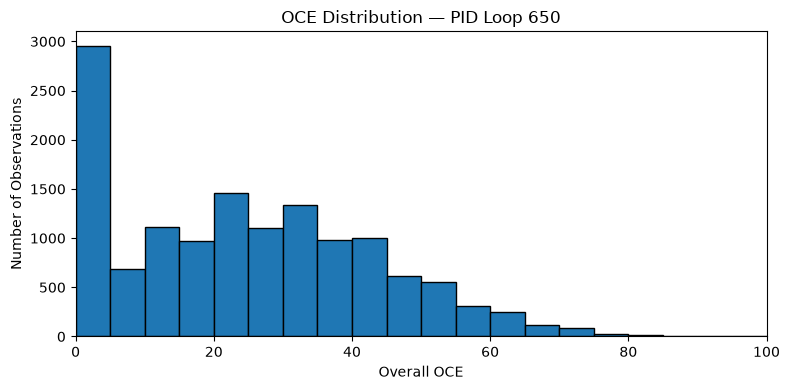

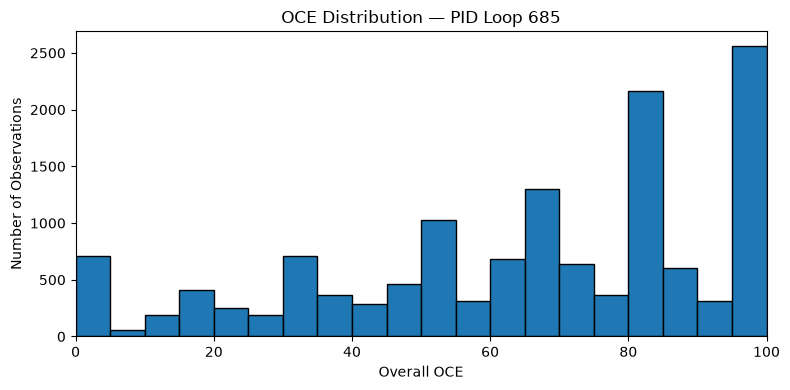

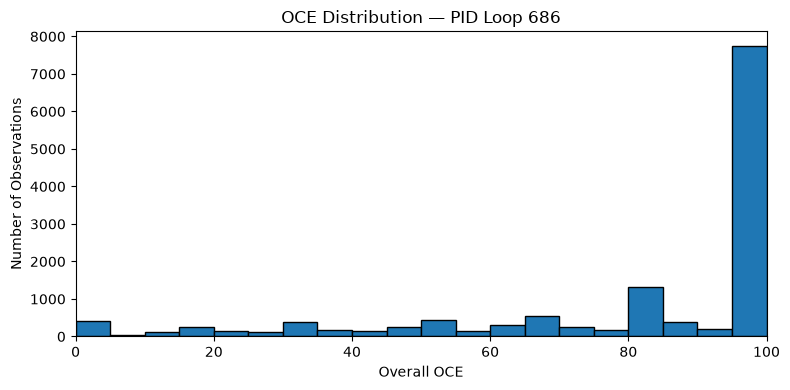

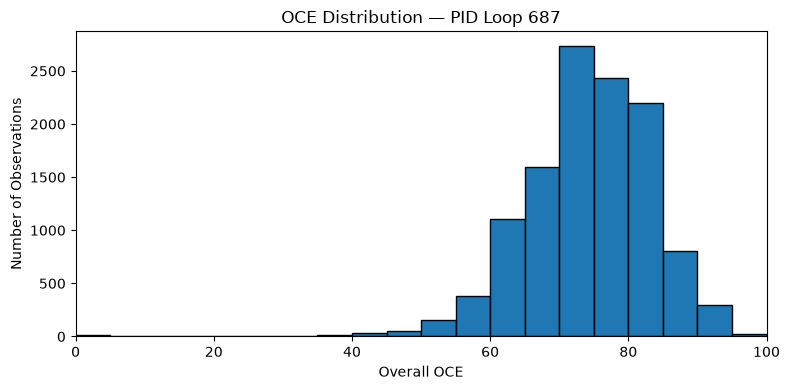

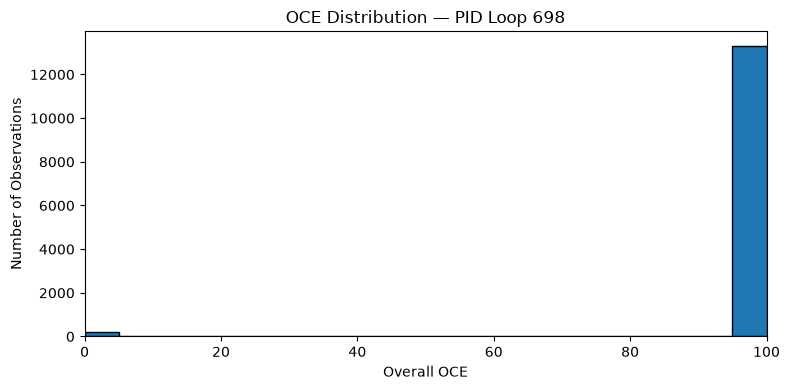

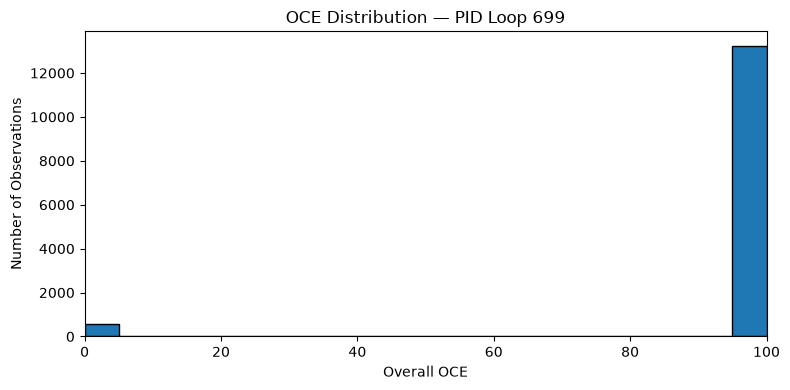

In [84]:
# Get all PID loops
loop_ids = sorted(df["LoopId"].dropna().unique())

# Create an OCE histogram for each PID loop
for loop_id in loop_ids:
    
    loop_data = df.loc[
        df["LoopId"] == loop_id,
        "OverallOCE"
    ].dropna()

    plt.figure(figsize=(8, 4))

    plt.hist(
        loop_data,
        bins=20,
        edgecolor="black"
    )

    plt.title(f"OCE Distribution — PID Loop {loop_id}")
    plt.xlabel("Overall OCE")
    plt.ylabel("Number of Observations")
    plt.xlim(0, 100)

    plt.tight_layout()
    plt.show()

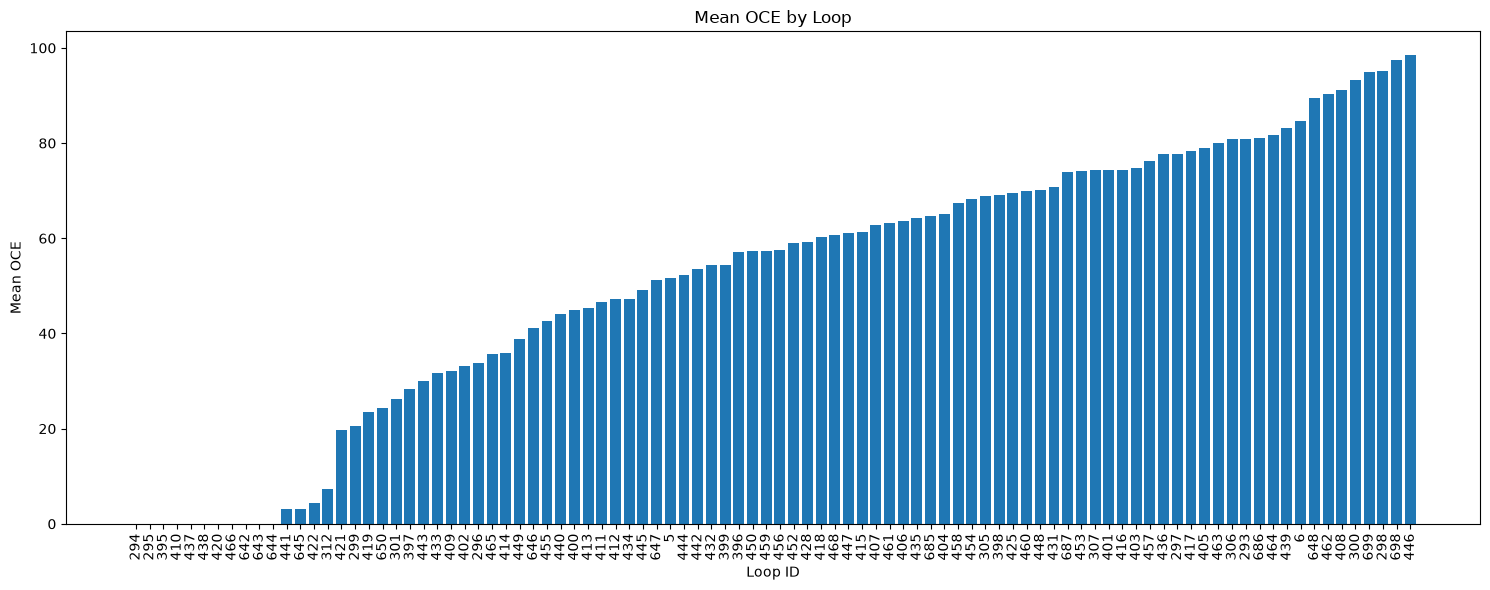

In [127]:
import matplotlib.pyplot as plt

plot_data = loop_ranking.sort_values("Mean_OCE")

plt.figure(figsize=(15, 6))

plt.bar(
    plot_data["LoopId"].astype(str),
    plot_data["Mean_OCE"]
)

plt.xlabel("Loop ID")
plt.ylabel("Mean OCE")
plt.title("Mean OCE by Loop")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

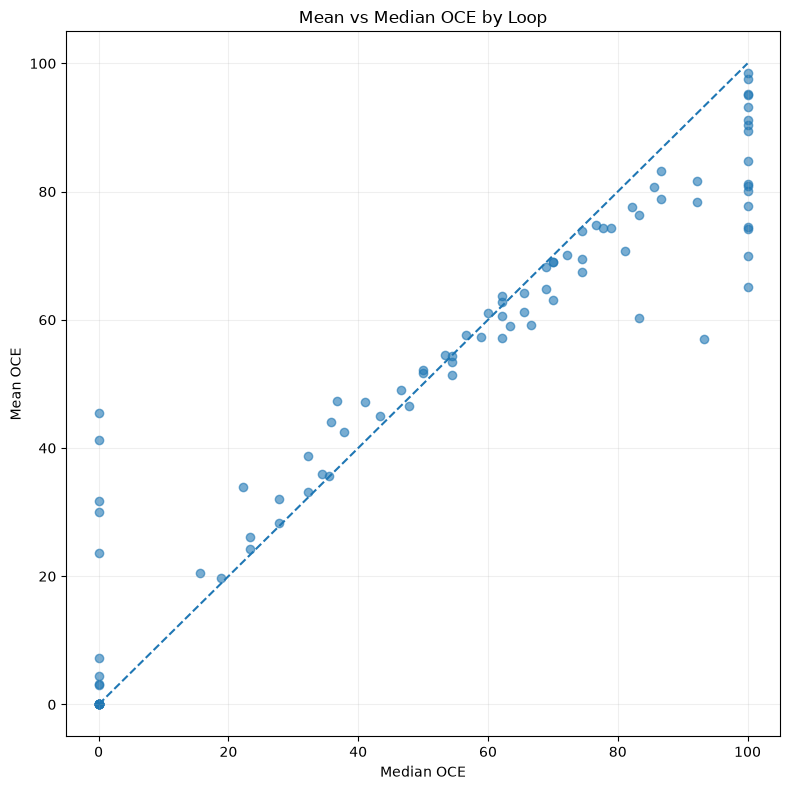

In [97]:
plt.figure(figsize=(8, 8))

plt.scatter(
    loop_stats["Median_OCE"],
    loop_stats["Mean_OCE"],
    alpha=0.6
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Median OCE")
plt.ylabel("Mean OCE")
plt.title("Mean vs Median OCE by Loop")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [128]:
variability_ranking = (
    loop_summary
    .sort_values("Std_OCE", ascending=False)
)

variability_ranking.head(10)

,LoopId,Mean_OCE,Median_OCE,Std_OCE,Observations
33,413,45.393413,0.000000,49.470764,13606
85,646,41.252988,0.000000,48.757817,13606
59,445,49.053520,46.666668,48.031995,13195
16,396,57.069101,93.333336,46.711709,13605
47,433,31.660617,0.000000,46.409574,13606
48,434,47.334809,36.660564,46.269963,13606
24,404,65.125464,100.000000,46.059909,13606
57,443,30.052366,0.000000,43.779361,14058
38,418,60.296802,83.333328,42.927105,13606
54,440,44.029994,35.805862,41.512215,1852


### 3.4 OCE Component Analysis

In [ ]:
# Create TimeNotSaturated by using Time Saturated
df["PercentageTimeNotSaturated"] = 1 - df["PercentTimeSaturated"]

In [ ]:
#oce component summary 
oce_components = [
    "PercentageTimeInNormalMode",
    "PercentageTimeNotSaturated",
    "AbsErrGoodFrac"
]

component_summary = df[oce_components].describe().T

component_summary

,count,mean,std,min,25%,50%,75%,max
PercentageTimeInNormalMode,1201478.0,0.941156,0.235111,0.0,1.000000,1.000000,1.0,1.0
PercentageTimeNotSaturated,1199198.0,0.890379,0.310789,0.0,1.000000,1.000000,1.0,1.0
AbsErrGoodFrac,1201478.0,0.641176,0.357077,0.0,0.366667,0.733333,1.0,1.0


In [143]:
loop_drivers = (
    df.groupby("LoopId")
      .agg(
          # OCE
          Mean_OCE=("OverallOCE", "mean"),
          Median_OCE=("OverallOCE", "median"),
          Std_OCE=("OverallOCE", "std"),

          # Normal Mode
          Mean_Normal=("PercentageTimeInNormalMode", "mean"),
          Median_Normal=("PercentageTimeInNormalMode", "median"),
          Std_Normal=("PercentageTimeInNormalMode", "std"),

          # Not Saturated
          Mean_NotSat=("PercentageTimeNotSaturated", "mean"),
          Median_NotSat=("PercentageTimeNotSaturated", "median"),
          Std_NotSat=("PercentageTimeNotSaturated", "std"),

          # Good Error
          Mean_GoodError=("AbsErrGoodFrac", "mean"),
          Median_GoodError=("AbsErrGoodFrac", "median"),
          Std_GoodError=("AbsErrGoodFrac", "std")
      )
      .reset_index()
)

loop_drivers.head()

,LoopId,Mean_OCE,Median_OCE,Std_OCE,Mean_Normal,Median_Normal,Std_Normal,Mean_NotSat,Median_NotSat,Std_NotSat,Mean_GoodError,Median_GoodError,Std_GoodError
0,5,51.669211,50.0,27.267471,0.947568,1.0,0.222434,0.997257,1.000000,0.050861,0.516913,0.5,0.272593
1,6,84.714066,100.0,35.909723,1.000000,1.0,0.000000,0.848060,1.000000,0.358418,0.887807,1.0,0.313261
2,293,80.854033,100.0,35.771695,0.850321,1.0,0.356219,0.999225,1.000000,0.025263,0.894753,1.0,0.207054
3,294,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.375624,0.021978,0.496037,0.000000,0.0,0.000000
4,295,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.377622,0.065934,0.494317,0.967677,1.0,0.058890


In [154]:
# Convert resulttime to datetime
df["resulttime"] = pd.to_datetime(df["resulttime"], errors="coerce")

print(df["resulttime"].dtype)

datetime64[ns, UTC]


In [155]:
loop_id = 5   # đổi thành LoopId bạn muốn investigate

selected_loop = (
    df[df["LoopId"] == loop_id]
    .copy()
    .sort_values("resulttime")
)

In [156]:
loop_daily = (
    selected_loop
    .set_index("resulttime")
    .resample("1D")
    .agg({
        "OverallOCE": "median",
        "PercentageTimeInNormalMode": "median",
        "PercentageTimeNotSaturated": "median",
        "AbsErrGoodFrac": "median"
    })
    .reset_index()
)

loop_daily

,resulttime,OverallOCE,PercentageTimeInNormalMode,PercentageTimeNotSaturated,AbsErrGoodFrac
0,2025-07-01 00:00:00+00:00,63.333332,1.0,1.0,0.633333
1,2025-07-02 00:00:00+00:00,57.777779,1.0,1.0,0.577778
2,2025-07-03 00:00:00+00:00,58.888889,1.0,1.0,0.588889
3,2025-07-04 00:00:00+00:00,73.333336,1.0,1.0,0.733333
4,2025-07-05 00:00:00+00:00,65.555557,1.0,1.0,0.655556
5,2025-07-06 00:00:00+00:00,64.444443,1.0,1.0,0.644444
6,2025-07-07 00:00:00+00:00,68.888893,1.0,1.0,0.688889
7,2025-07-08 00:00:00+00:00,58.888889,1.0,1.0,0.588889
8,2025-07-09 00:00:00+00:00,50.000000,1.0,1.0,0.500000
9,2025-07-10 00:00:00+00:00,50.000000,1.0,1.0,0.500000


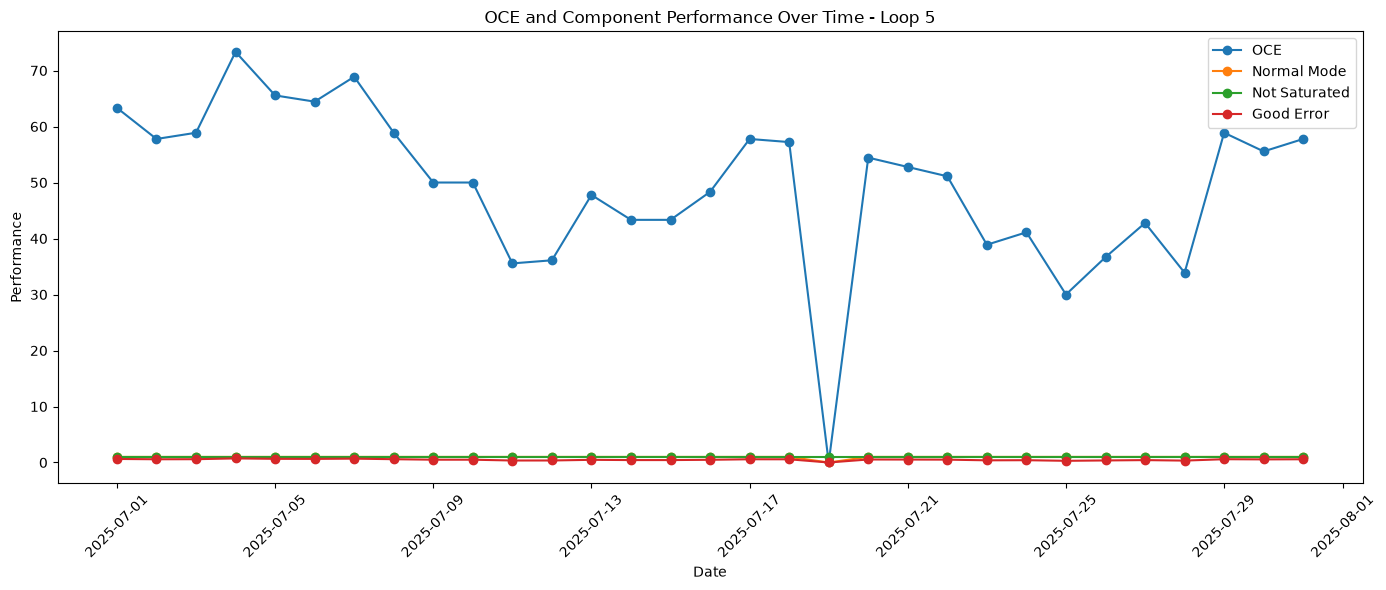

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    loop_daily["resulttime"],
    loop_daily["OverallOCE"],
    marker="o",
    label="OCE"
)

plt.plot(
    loop_daily["resulttime"],
    loop_daily["PercentageTimeInNormalMode"],
    marker="o",
    label="Normal Mode"
)

plt.plot(
    loop_daily["resulttime"],
    loop_daily["PercentageTimeNotSaturated"],
    marker="o",
    label="Not Saturated"
)

plt.plot(
    loop_daily["resulttime"],
    loop_daily["AbsErrGoodFrac"],
    marker="o",
    label="Good Error"
)

plt.title(f"OCE and Component Performance Over Time - Loop {loop_id}")
plt.xlabel("Date")
plt.ylabel("Performance")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [160]:
# ==========================================
# DAILY COMPONENT PERFORMANCE - ALL LOOPS
# ==========================================

df["resulttime"] = pd.to_datetime(df["resulttime"])

loop_daily_all = (
    df.groupby([
        "LoopId",
        pd.Grouper(key="resulttime", freq="1D")
    ])
    .agg(
        OCE=("OverallOCE", "median"),
        Normal=("PercentageTimeInNormalMode", "median"),
        NotSat=("PercentageTimeNotSaturated", "median"),
        GoodError=("AbsErrGoodFrac", "median")
    )
    .reset_index()
)

loop_daily_all.head()

,LoopId,resulttime,OCE,Normal,NotSat,GoodError
0,5,2025-07-01 00:00:00+00:00,63.333332,1.0,1.0,0.633333
1,5,2025-07-02 00:00:00+00:00,57.777779,1.0,1.0,0.577778
2,5,2025-07-03 00:00:00+00:00,58.888889,1.0,1.0,0.588889
3,5,2025-07-04 00:00:00+00:00,73.333336,1.0,1.0,0.733333
4,5,2025-07-05 00:00:00+00:00,65.555557,1.0,1.0,0.655556


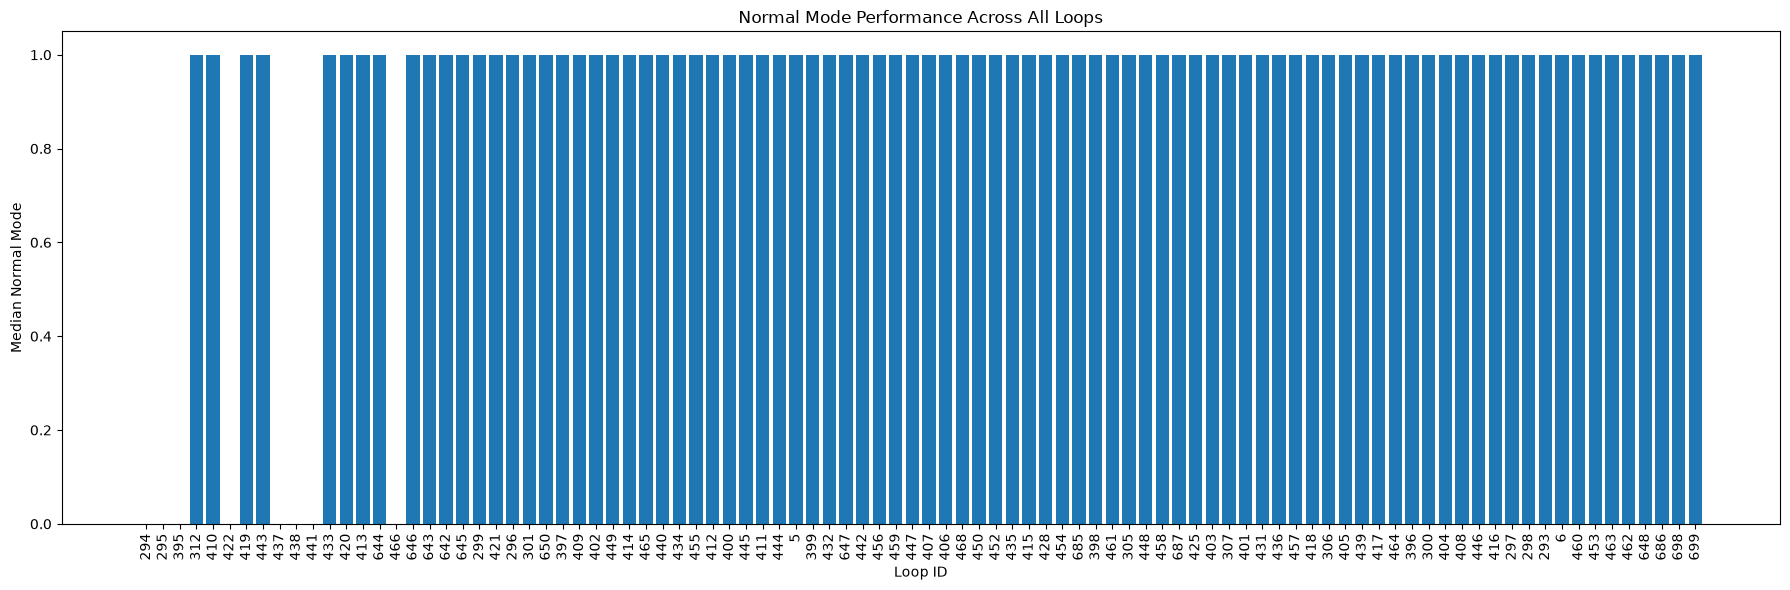

In [165]:
#Normal mode component
plt.figure(figsize=(18, 6))

plt.bar(
    plot_data["LoopId"].astype(str),
    plot_data["Median_Normal"]
)

plt.title("Normal Mode Performance Across All Loops")
plt.xlabel("Loop ID")
plt.ylabel("Median Normal Mode")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

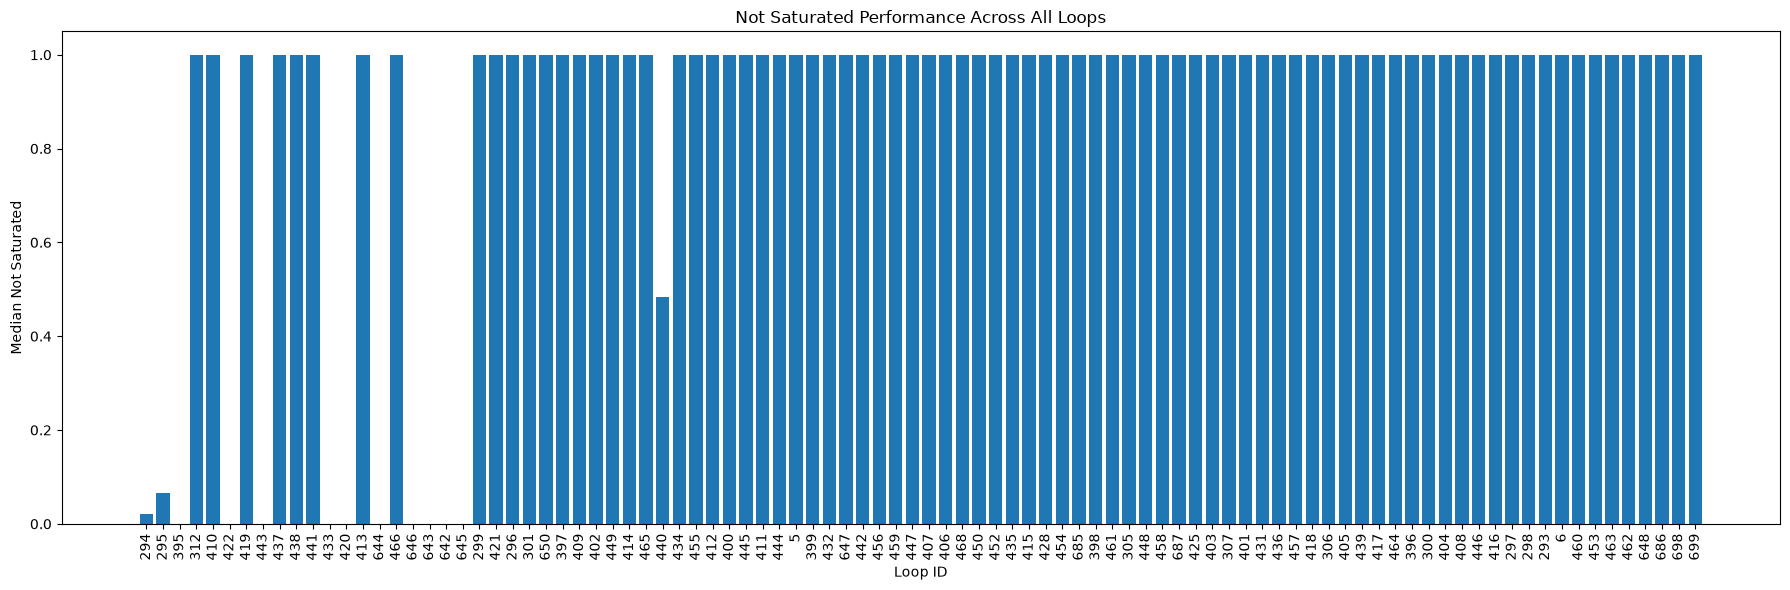

In [166]:
# Not Saturated component
plt.figure(figsize=(18, 6))

plt.bar(
    plot_data["LoopId"].astype(str),
    plot_data["Median_NotSat"]
)

plt.title("Not Saturated Performance Across All Loops")
plt.xlabel("Loop ID")
plt.ylabel("Median Not Saturated")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

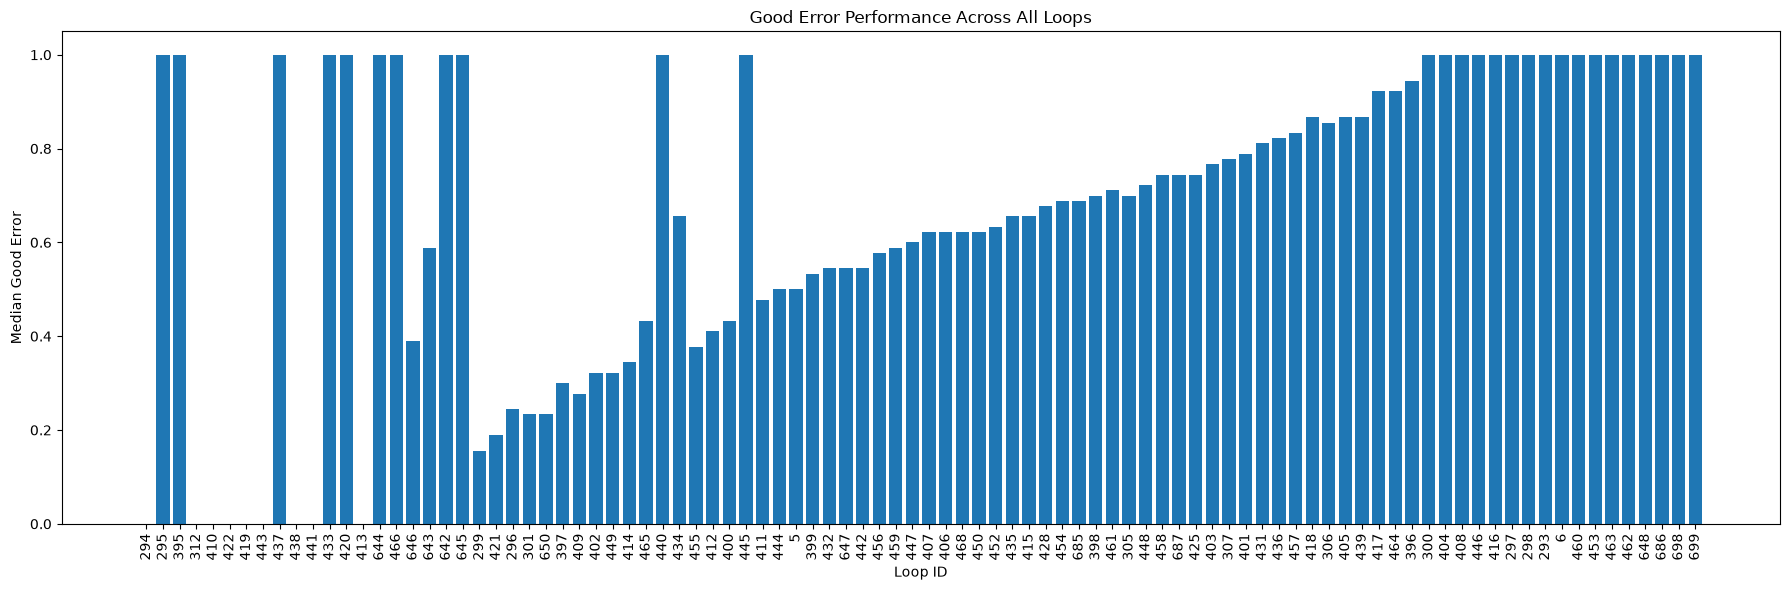

In [167]:
# Good error component
plt.figure(figsize=(18, 6))

plt.bar(
    plot_data["LoopId"].astype(str),
    plot_data["Median_GoodError"]
)

plt.title("Good Error Performance Across All Loops")
plt.xlabel("Loop ID")
plt.ylabel("Median Good Error")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [168]:
#All 3 component, but 50% number of loops
import numpy as np

midpoint = len(plot_data) // 2

first_half = plot_data.iloc[:midpoint]
second_half = plot_data.iloc[midpoint:]

In [172]:
# Function for not duplicate code
def plot_component_comparison(data, title):

    x = np.arange(len(data))
    width = 0.27

    plt.figure(figsize=(18, 7))

    plt.bar(
        x - width,
        data["Median_Normal"],
        width,
        label="Normal Mode"
    )

    plt.bar(
        x,
        data["Median_NotSat"],
        width,
        label="Not Saturated"
    )

    plt.bar(
        x + width,
        data["Median_GoodError"],
        width,
        label="Good Error"
    )

    plt.xticks(
        x,
        data["LoopId"].astype(str),
        rotation=90
    )

    plt.xlabel("Loop ID")
    plt.ylabel("Median Component Performance")

    plt.title(title)

    plt.legend()

    plt.tight_layout()
    plt.show()

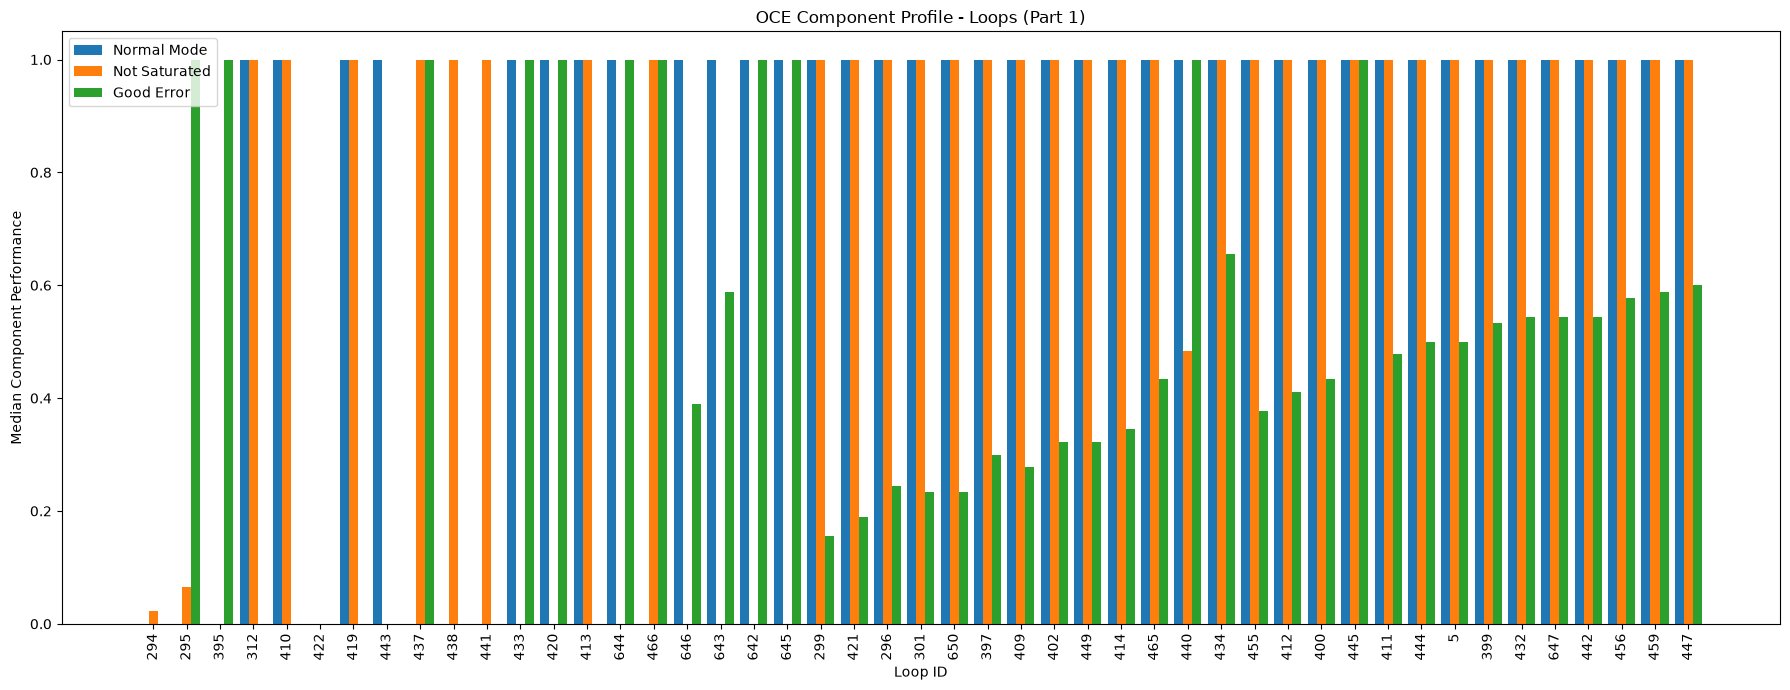

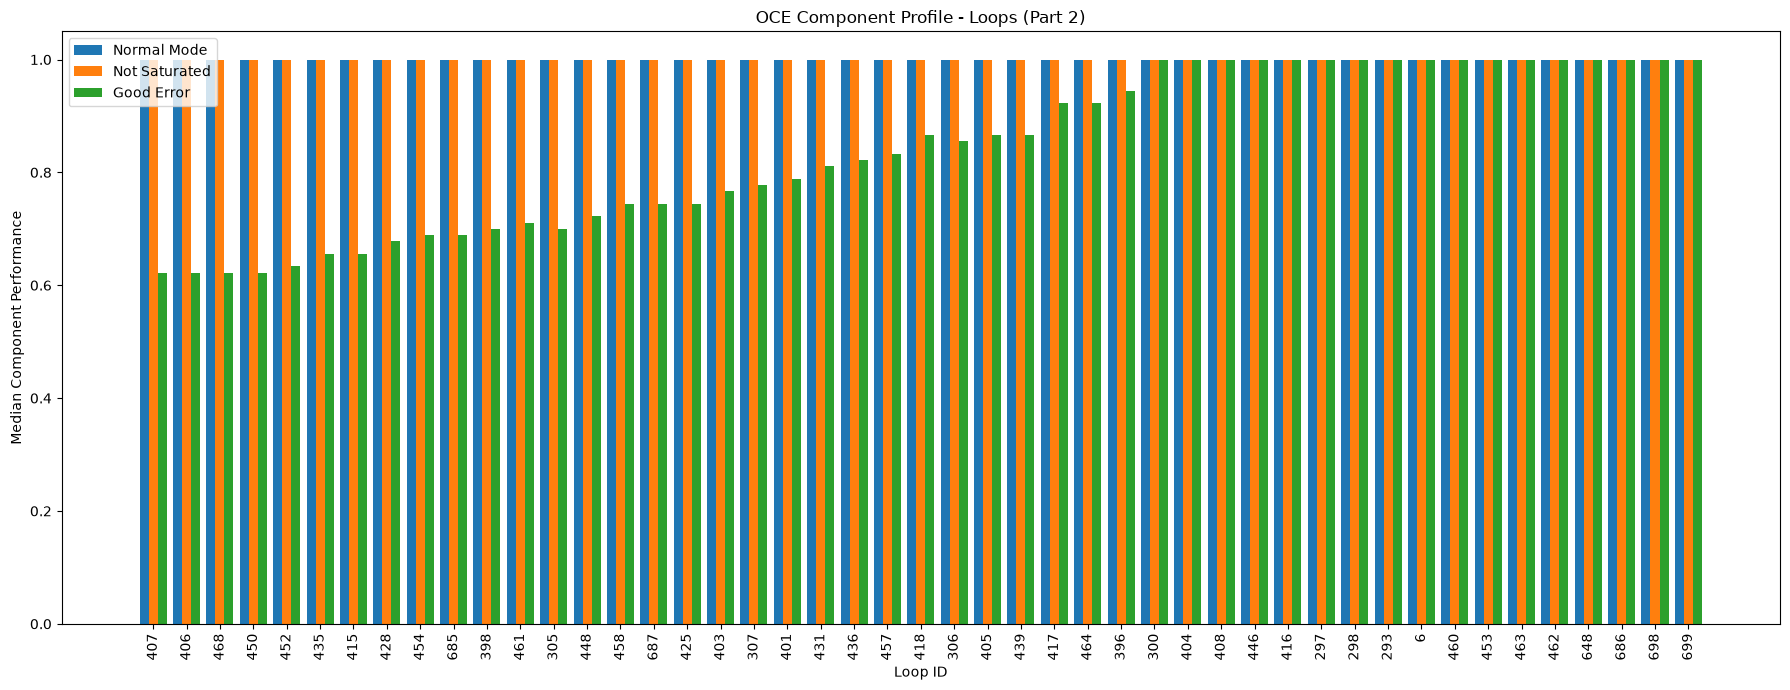

In [173]:
# First 50% loops 
plot_component_comparison(
    first_half,
    "OCE Component Profile - Loops (Part 1)"
)

# 50% loops 

plot_component_comparison(
    second_half,
    "OCE Component Profile - Loops (Part 2)"
)